In [23]:
# 0. import libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
mpl.rcParams['text.usetex'] = False  # Set to False since LaTeX is not installed; matplotlib's built-in math rendering will still work
import os
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
import statsmodels.api as sm
pd.options.mode.chained_assignment = None


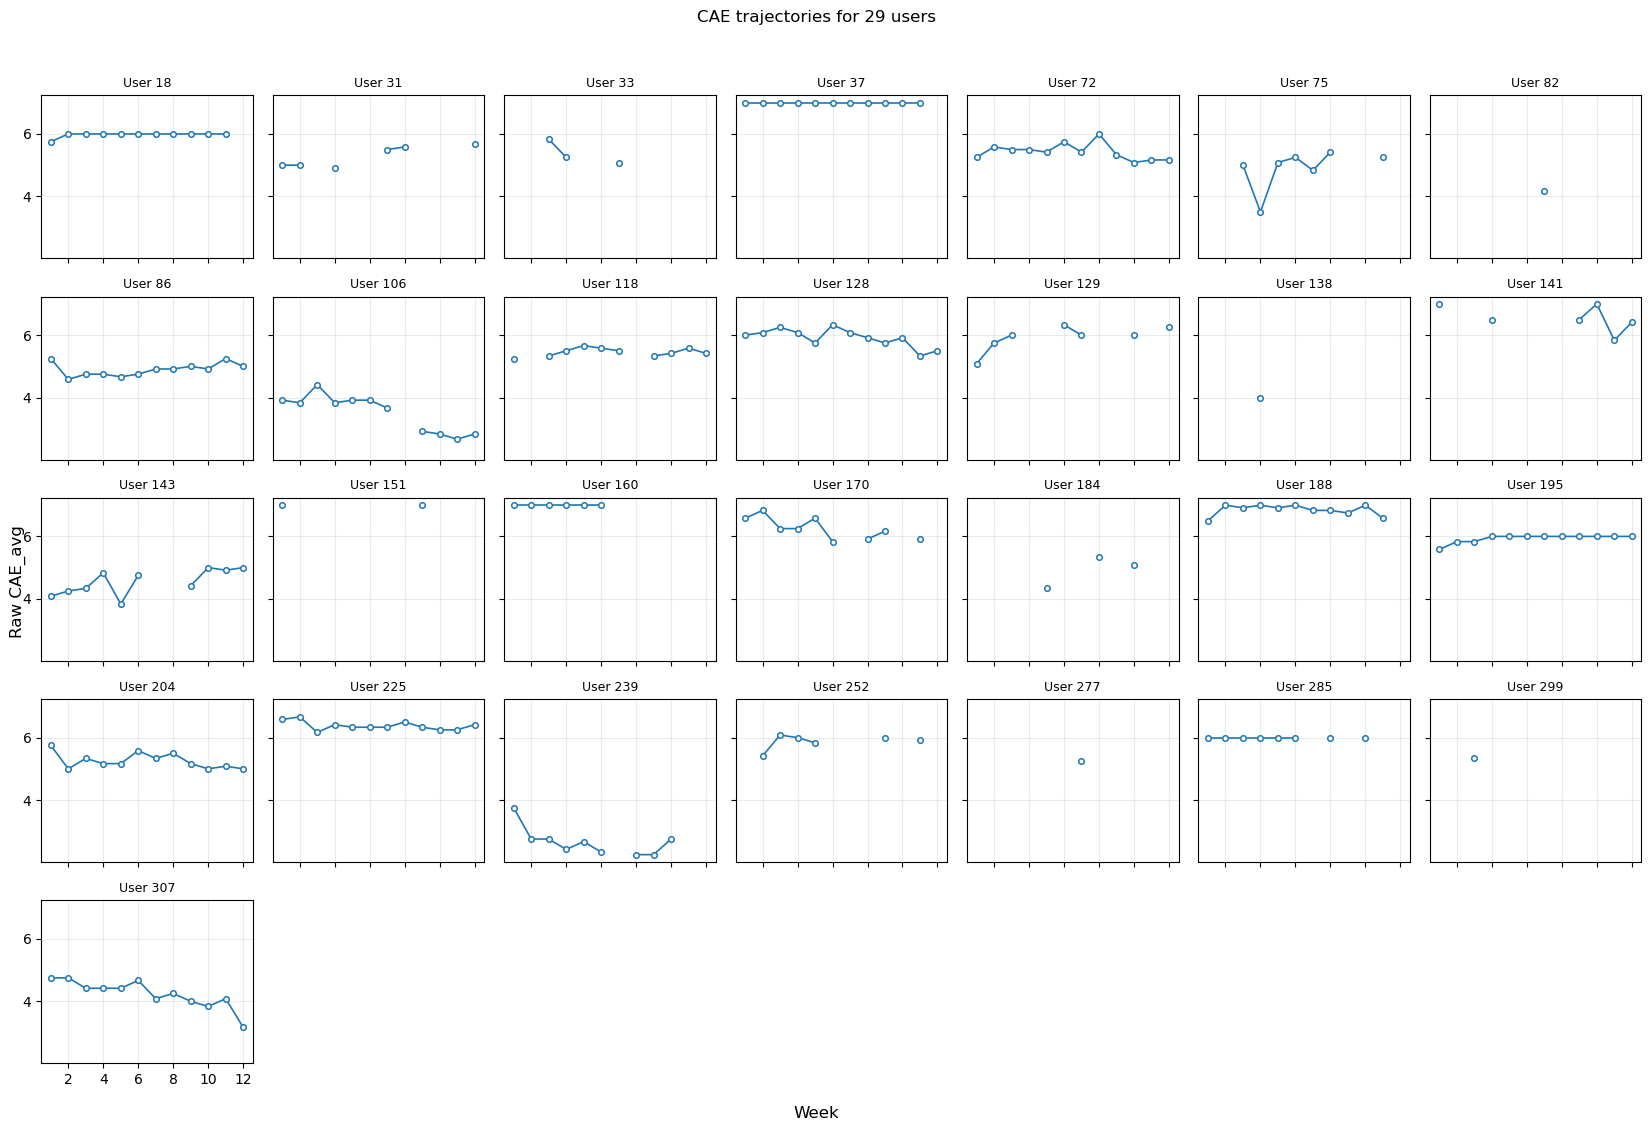

Loaded /Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPT_MRT/Xueqing/df_merged.csv
Plotted 29 users with at least one observed CAE value; missing weeks remain NaN.


In [24]:
# CAE trajectories from raw df_merged.csv; missing CAE values are left as NaN.
from pathlib import Path
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

folder = Path("/Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPT_MRT/Xueqing")
df_merged_path = folder / "df_merged.csv"
if not df_merged_path.is_file():
    raise FileNotFoundError(f"Could not find {df_merged_path}")

df_merged_cae = pd.read_csv(df_merged_path)
df_merged_cae["Date"] = pd.to_datetime(df_merged_cae["Date"], errors="coerce")

user_col = "ParticipantIdentifier"
week_col = "week"
cae_col = "CAE_avg"
required_cols = [user_col, week_col, cae_col]
missing_cols = [c for c in required_cols if c not in df_merged_cae.columns]
if missing_cols:
    raise KeyError(f"df_merged is missing required CAE trajectory columns: {missing_cols}")

sort_cols = [user_col, week_col]
if "Date" in df_merged_cae.columns:
    sort_cols.append("Date")
if "DecisionTime" in df_merged_cae.columns:
    sort_cols.append("DecisionTime")

def _first_observed_or_nan(values):
    observed = values.dropna()
    return np.nan if observed.empty else observed.iloc[0]

# df_merged has repeated decision-slot rows; summarize to one weekly CAE point without filling missing weeks.
weekly_cae = (
    df_merged_cae.sort_values(sort_cols)
    .groupby([user_col, week_col], as_index=False)[cae_col]
    .agg(_first_observed_or_nan)
)

observed_counts = weekly_cae.groupby(user_col)[cae_col].apply(lambda s: s.notna().sum())
users = observed_counts[observed_counts > 0].index.to_numpy()
users = np.array(sorted(users), dtype=int)
n_users = len(users)
if n_users == 0:
    raise ValueError("No users with observed CAE values found in df_merged.")

all_weeks = np.arange(int(weekly_cae[week_col].min()), int(weekly_cae[week_col].max()) + 1)
ncols = 7 if n_users >= 7 else n_users
nrows = math.ceil(n_users / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(2.4 * ncols, 2.2 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, uid in zip(axes, users):
    user_weekly = (
        weekly_cae.loc[weekly_cae[user_col] == uid]
        .set_index(week_col)
        .reindex(all_weeks)
    )
    ax.plot(
        all_weeks,
        user_weekly[cae_col],
        color="tab:blue",
        marker="o",
        markerfacecolor="white",
        markeredgewidth=1.1,
        linewidth=1.2,
        markersize=4,
    )
    ax.set_title(f"User {uid}", fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

for ax in axes[n_users:]:
    ax.set_visible(False)

fig.suptitle(f"CAE trajectories for {n_users} users", fontsize=12, y=1.02)
fig.supxlabel("Week")
fig.supylabel("Raw CAE_avg")
fig.tight_layout()
plt.show()

print(f"Loaded {df_merged_path}")
print(f"Plotted {n_users} users with at least one observed CAE value; missing weeks remain NaN.")


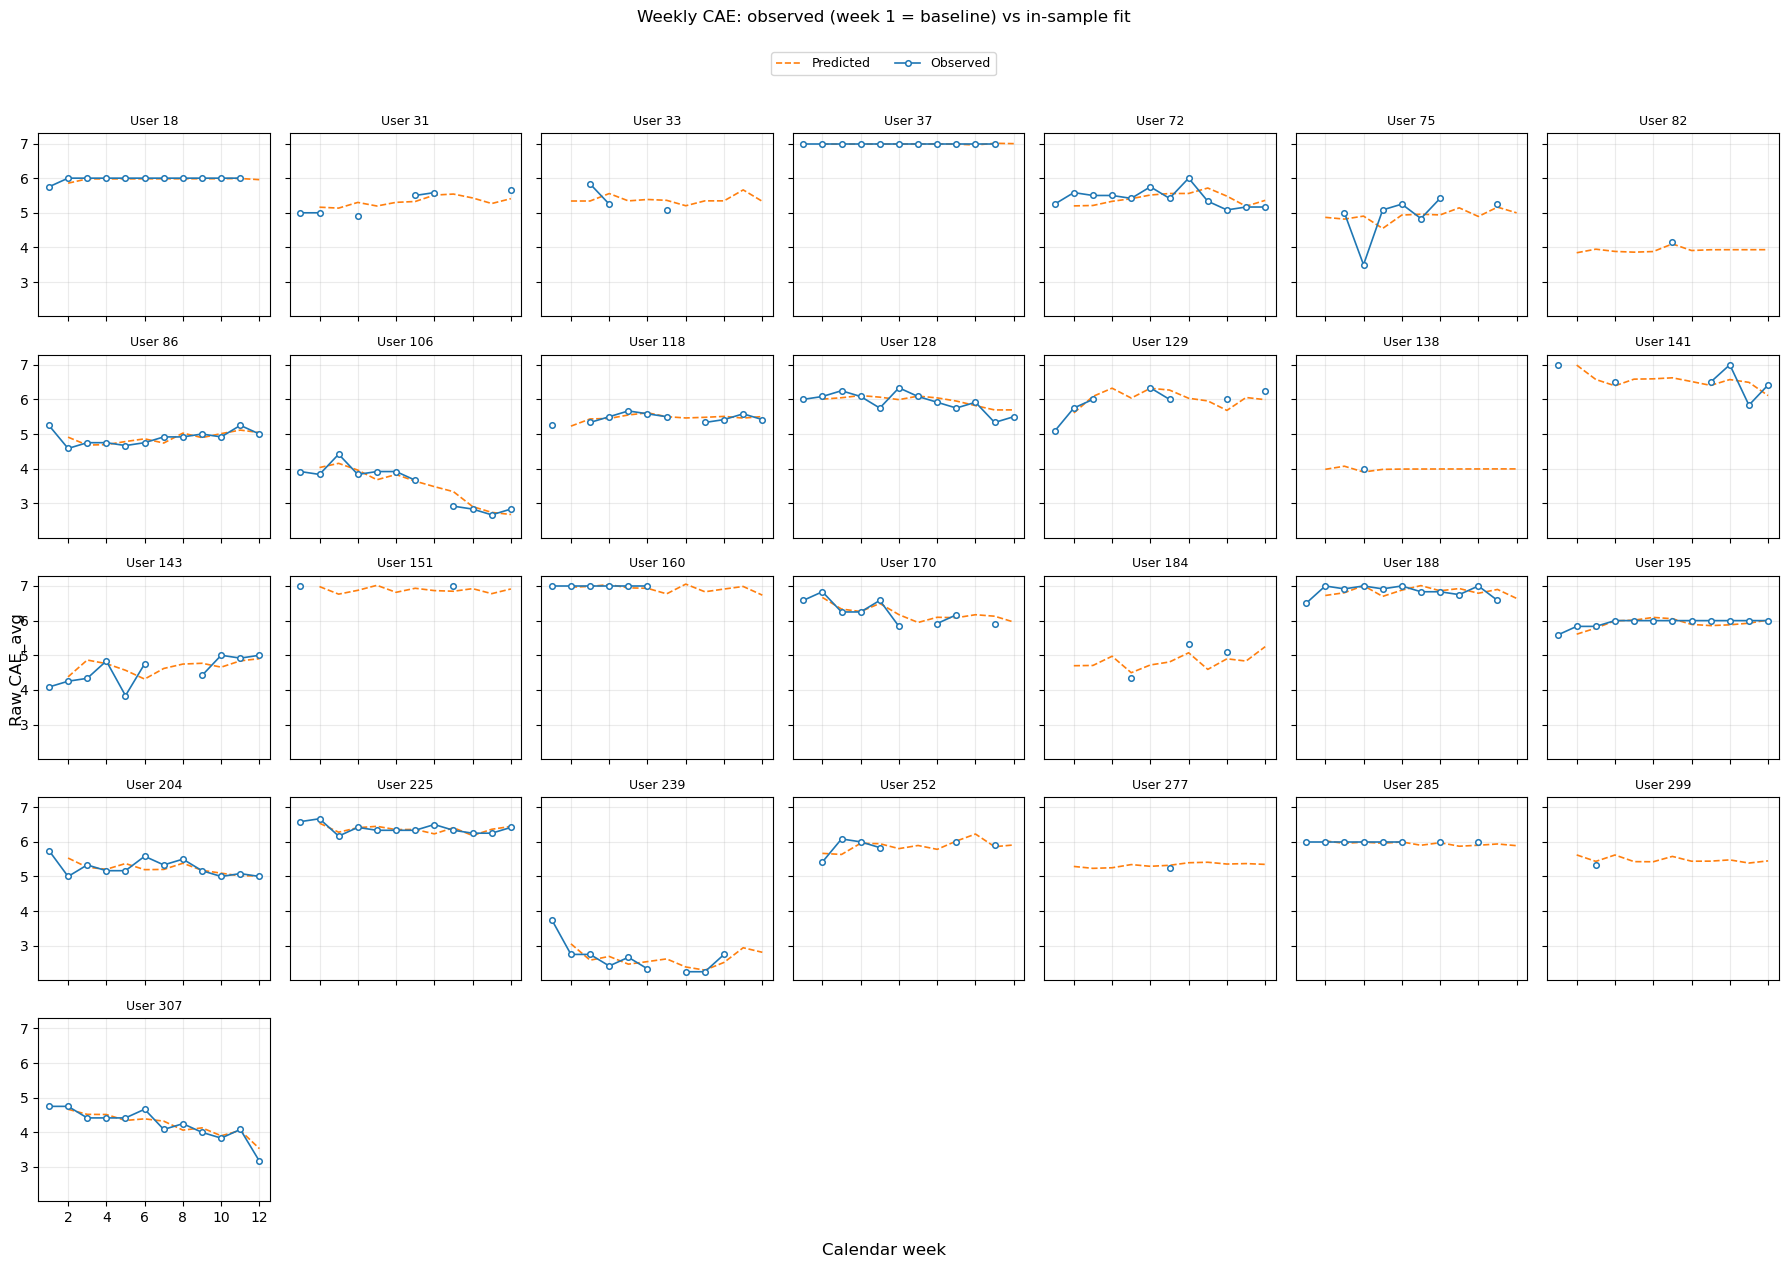

,n_obs,mean_obs,mean_pred,mae,rmse,max_abs_err,constant_pred
user,,,,,,,
18,10,6.000,5.969,0.031,0.049,0.145,False
31,5,5.333,5.341,0.210,0.234,0.383,False
33,3,5.389,5.419,0.358,0.371,0.493,False
37,10,7.000,6.983,0.018,0.020,0.043,False
72,11,5.447,5.411,0.242,0.281,0.441,False
75,7,4.905,4.895,0.447,0.614,1.404,False
82,1,4.167,4.102,0.065,0.065,0.065,False
86,11,4.864,4.887,0.122,0.143,0.326,False
106,10,3.483,3.495,0.166,0.200,0.419,False


Plotted 29 users from /Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPR-MRT-Testbed/env_para_vanilla/user_ids.txt
Predictions loaded from /Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPR-MRT-Testbed/env_para_vanilla/pred_<userid>.json
Observed CAE from /Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPT_MRT/Xueqing/df_merged.csv (week 1 baseline from /Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPR-MRT-Testbed/env_para_vanilla/df_fit_11week.csv)


In [25]:
# Observed vs in-sample predicted weekly CAE for the vanilla testbed users.
# Observed (blue): ``CAE_avg`` from ``df_merged.csv`` (weeks 2–12), with week 1 set to baseline
#   ``CAE_avg_lastweek`` at vanilla week 1 from ``df_fit_11week.csv`` (same as calendar week 2's lagged CAE).
# Predicted (orange): ``pred_CAE`` for calendar weeks 2–12 only (week 1 baseline is not fitted).
from pathlib import Path
import math
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

PROJECT_ROOT = Path(".").resolve()
if not (PROJECT_ROOT / "env_para_vanilla").exists() and (PROJECT_ROOT.parent / "env_para_vanilla").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

work_folder = PROJECT_ROOT / "env_para_vanilla"
combined_folder = Path("/Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPT_MRT/Xueqing")
df_merged_path = combined_folder / "df_merged.csv"
df_fit_11week_path = work_folder / "df_fit_11week.csv"
file_pred_prefix = work_folder / "pred_"
file_user_ids = work_folder / "user_ids.txt"

if not df_merged_path.is_file():
    raise FileNotFoundError(f"Could not find {df_merged_path}")
if not df_fit_11week_path.is_file():
    raise FileNotFoundError(f"Could not find {df_fit_11week_path}")
if not file_user_ids.is_file():
    raise FileNotFoundError(f"Could not find {file_user_ids}")

with open(work_folder / "std_params.json", encoding="utf-8") as f:
    _std = json.load(f)
_cae_shift = float(_std["CAE_avg_shift"])
_cae_scale = float(_std["CAE_avg_scale"])


def denormalize_CAE(cae_norm):
    return _cae_shift + _cae_scale * np.asarray(cae_norm, dtype=float)


def _first_observed_or_nan(values):
    observed = values.dropna()
    return np.nan if observed.empty else observed.iloc[0]


userid_all = np.atleast_1d(np.loadtxt(file_user_ids, dtype=int)).astype(int)
n_users = len(userid_all)

# Predictions cover calendar weeks 2–12; week 1 is baseline only (prepended to observed line).
VANILLA_NWEEK = 11
calendar_weeks_all = np.arange(1, 13, dtype=int)
calendar_weeks_fit = np.arange(2, 2 + VANILLA_NWEEK, dtype=int)

user_col = "ParticipantIdentifier"
week_col = "week"
cae_col = "CAE_avg"
cae_lastweek_col = "CAE_avg_lastweek"

df_merged_cae = pd.read_csv(df_merged_path)
df_merged_cae["Date"] = pd.to_datetime(df_merged_cae["Date"], errors="coerce")

df_fit_lw = pd.read_csv(df_fit_11week_path)
if "Date" in df_fit_lw.columns:
    df_fit_lw["Date"] = pd.to_datetime(df_fit_lw["Date"], errors="coerce")

sort_cols = [user_col, week_col]
if "Date" in df_merged_cae.columns:
    sort_cols.append("Date")
if "DecisionTime" in df_merged_cae.columns:
    sort_cols.append("DecisionTime")

fit_sort_cols = [user_col, week_col]
if "Date" in df_fit_lw.columns:
    fit_sort_cols.append("Date")
if "DecisionTime" in df_fit_lw.columns:
    fit_sort_cols.append("DecisionTime")

weekly_cae = (
    df_merged_cae.sort_values(sort_cols)
    .groupby([user_col, week_col], as_index=False)[cae_col]
    .agg(_first_observed_or_nan)
)

weekly_cae_lastweek = (
    df_fit_lw.sort_values(fit_sort_cols)
    .groupby([user_col, week_col], as_index=False)[cae_lastweek_col]
    .agg(_first_observed_or_nan)
)

ncols = 7 if n_users >= 7 else n_users
nrows = math.ceil(n_users / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(2.6 * ncols, 2.4 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

summary_rows = []
for ax, uid in zip(axes, userid_all):
    pred_path = Path(f"{file_pred_prefix}{int(uid)}.json")
    if not pred_path.is_file():
        ax.set_title(f"User {uid} (missing pred)", fontsize=9)
        ax.set_visible(False)
        summary_rows.append(
            {
                "user": int(uid),
                "n_obs": np.nan,
                "mean_obs": np.nan,
                "mean_pred": np.nan,
                "mae": np.nan,
                "rmse": np.nan,
                "max_abs_err": np.nan,
                "constant_pred": np.nan,
            }
        )
        continue

    pred_norm = np.asarray(json.loads(pred_path.read_text(encoding="utf-8"))["pred_CAE"], dtype=float)
    if pred_norm.size != VANILLA_NWEEK:
        pred_norm = pred_norm[:VANILLA_NWEEK]
    pred_raw = denormalize_CAE(pred_norm)

    user_weekly_fit = (
        weekly_cae.loc[weekly_cae[user_col] == uid]
        .set_index(week_col)
        .reindex(calendar_weeks_fit)[cae_col]
        .to_numpy(dtype=float)
    )
    user_weekly_all = (
        weekly_cae.loc[weekly_cae[user_col] == uid]
        .set_index(week_col)
        .reindex(calendar_weeks_all)[cae_col]
        .to_numpy(dtype=float)
    )
    baseline_rows = weekly_cae_lastweek.loc[
        (weekly_cae_lastweek[user_col] == uid) & (weekly_cae_lastweek[week_col] == 1),
        cae_lastweek_col,
    ]
    if not baseline_rows.empty and np.isfinite(baseline_rows.iloc[0]):
        user_weekly_all[0] = float(baseline_rows.iloc[0])

    obs_mask = np.isfinite(user_weekly_fit)
    n_obs = int(obs_mask.sum())
    if n_obs > 0:
        obs_vals = user_weekly_fit[obs_mask]
        pred_at_obs = pred_raw[obs_mask]
        err = pred_at_obs - obs_vals
        mean_obs = float(np.mean(obs_vals))
        mean_pred = float(np.mean(pred_at_obs))
        mae = float(np.mean(np.abs(err)))
        rmse = float(np.sqrt(np.mean(err ** 2)))
        max_abs_err = float(np.max(np.abs(err)))
    else:
        mean_obs = mean_pred = mae = rmse = max_abs_err = np.nan

    summary_rows.append(
        {
            "user": int(uid),
            "n_obs": n_obs,
            "mean_obs": mean_obs,
            "mean_pred": mean_pred,
            "mae": mae,
            "rmse": rmse,
            "max_abs_err": max_abs_err,
            "constant_pred": bool(np.nanstd(pred_raw) < 1e-6),
        }
    )

    ax.plot(
        calendar_weeks_fit,
        pred_raw,
        color="tab:orange",
        linestyle="--",
        linewidth=1.2,
        label="Predicted",
    )
    ax.plot(
        calendar_weeks_all,
        user_weekly_all,
        color="tab:blue",
        marker="o",
        markerfacecolor="white",
        markeredgewidth=1.1,
        linewidth=1.2,
        markersize=4,
        label="Observed",
    )
    ax.set_title(f"User {uid}", fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

for ax in axes[n_users:]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02), fontsize=9)

fig.suptitle(
    "Weekly CAE: observed (week 1 = baseline) vs in-sample fit",
    fontsize=12,
    y=1.05,
)
fig.supxlabel("Calendar week")
fig.supylabel("Raw CAE_avg")
fig.tight_layout()
plt.show()

cae_fit_summary = pd.DataFrame(summary_rows).set_index("user")
cae_fit_summary = cae_fit_summary.sort_index()
display(
    cae_fit_summary.style.format(
        {
            "n_obs": "{:.0f}",
            "mean_obs": "{:.3f}",
            "mean_pred": "{:.3f}",
            "mae": "{:.3f}",
            "rmse": "{:.3f}",
            "max_abs_err": "{:.3f}",
        },
        na_rep="—",
    ).set_caption(
        "In-sample CAE fit summary at calendar weeks 2–12 only "
        "(week 1 baseline excluded; metrics compare predicted vs observed at weeks with data)."
    )
)

print(f"Plotted {n_users} users from {file_user_ids}")
print(f"Predictions loaded from {work_folder / 'pred_<userid>.json'}")
print(f"Observed CAE from {df_merged_path} (week 1 baseline from {df_fit_11week_path})")

In [26]:
from pathlib import Path
import math
import re
from matplotlib.colors import TwoSlopeNorm

PROJECT_ROOT = Path(".").resolve()
if not (PROJECT_ROOT / "env_para_vanilla").exists() and (PROJECT_ROOT.parent / "env_para_vanilla").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

work_folder = PROJECT_ROOT / "env_para_vanilla"
file_params_env_prefix = str(work_folder / "params_env_")
file_pred_prefix = str(work_folder / "pred_")
file_user_ids = work_folder / "user_ids.txt"

if file_user_ids.is_file():
    userid_all = np.atleast_1d(np.loadtxt(file_user_ids, dtype=int)).astype(int)
else:
    userid_all = np.array(
        sorted(
            int(m.group(1))
            for p in work_folder.glob("params_env_*.json")
            if (m := re.match(r"params_env_(\d+)\.json$", p.name))
        ),
        dtype=int,
    )

if userid_all.size == 0:
    raise FileNotFoundError(f"No participants found in {work_folder}")

# Residual-plot layout: ceil(n_users/2) columns so odd counts (e.g. 11) do not drop a user
def _resid_axes(n_users, figsize=(10, 4)):
    ncols = max(1, int(math.ceil(n_users / 2.0)))
    fig, axes = plt.subplots(2, ncols, figsize=(figsize[0] * ncols / 5, figsize[1]), constrained_layout=True)
    if ncols == 1:
        axes = np.array(axes).reshape(2, 1)
    return fig, axes, ncols

def _align_pred_resid(pred, resid):
    """Truncate pred/resid to common length, then keep finite pairs only."""
    pred = np.asarray(pred, dtype=float).ravel()
    resid = np.asarray(resid, dtype=float).ravel()
    n = min(pred.size, resid.size)
    pred, resid = pred[:n], resid[:n]
    m = np.isfinite(pred) & np.isfinite(resid)
    return pred[m], resid[m]

_SAMPLE_PARAM = Path(file_params_env_prefix + str(int(userid_all[0])) + ".json")
if _SAMPLE_PARAM.is_file():
    _sk = sorted(json.loads(_SAMPLE_PARAM.read_text()).keys())
    print("Sample params_env keys:", _sk)
    _pp = Path(file_pred_prefix + str(int(userid_all[0])) + ".json")
    if _pp.is_file():
        print("Sample pred_ keys:", sorted(json.loads(_pp.read_text()).keys()))


Sample params_env keys: ['_query_interaction_impute', 'alpha_CAE_l2', 'alpha_CAE_short_avg_l2', 'alpha_active_status_l2', 'alpha_anticipated_affect_l2', 'alpha_fourSC_l2', 'alpha_prior2hour_step_count_l2', 'alpha_recorded_physical_activity_l2', 'alpha_ws_interaction_l2', 'resid_CAE', 'resid_CAE_short_avg', 'resid_active_status', 'resid_antic', 'resid_fourSC', 'resid_ml_J_week', 'resid_ml_U1', 'resid_ml_U2', 'resid_ml_daily_present', 'resid_ml_hourly_pageview', 'resid_ml_nextday_wearing', 'resid_prior2hour_step_count', 'resid_recorded_physical_activity', 'resid_ws_interaction', 'theta_CAE', 'theta_CAE_names', 'theta_CAE_short_avg', 'theta_CAE_short_avg_names', 'theta_active_status', 'theta_active_status_names', 'theta_antic', 'theta_antic_names', 'theta_fourSC', 'theta_fourSC_names', 'theta_ml_Ew', 'theta_ml_Ew_names', 'theta_ml_FW', 'theta_ml_FW_names', 'theta_ml_J', 'theta_ml_J_names', 'theta_ml_PJ', 'theta_ml_PJ_names', 'theta_ml_PV', 'theta_ml_PV_names', 'theta_ml_U1', 'theta_ml_U1_


4_perceived_utility.py: joint perceived-utility ML model
  plot theta_ml_Ew: 29 participants x 6 coefficients


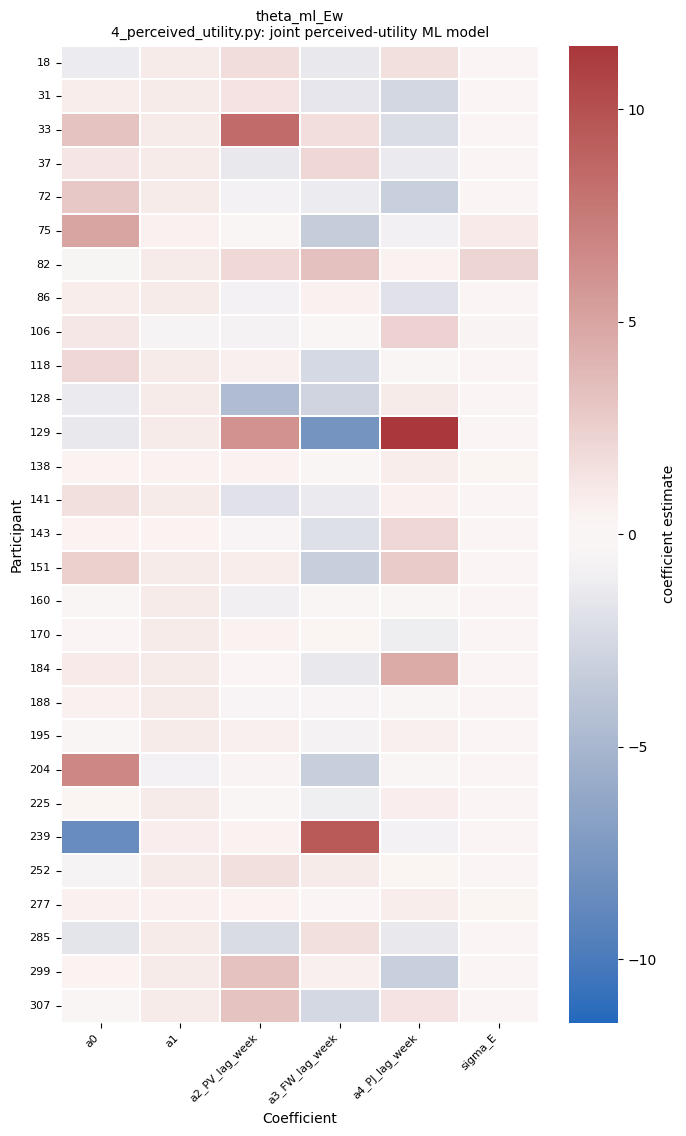

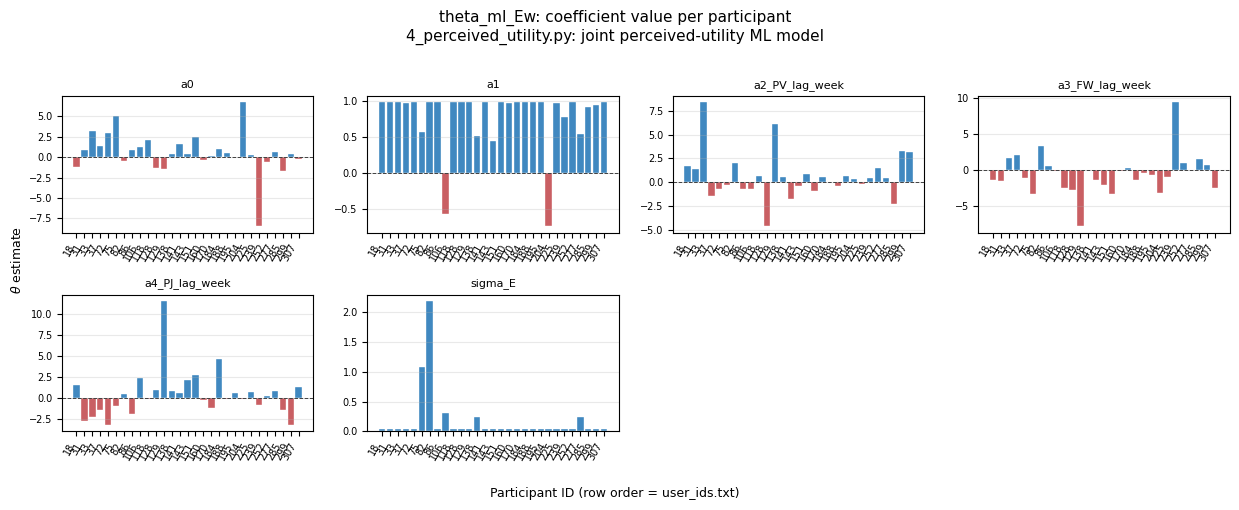

  skip theta_ml_E1_prior: not found in params_env_*.json
  plot theta_ml_J: 29 participants x 2 coefficients


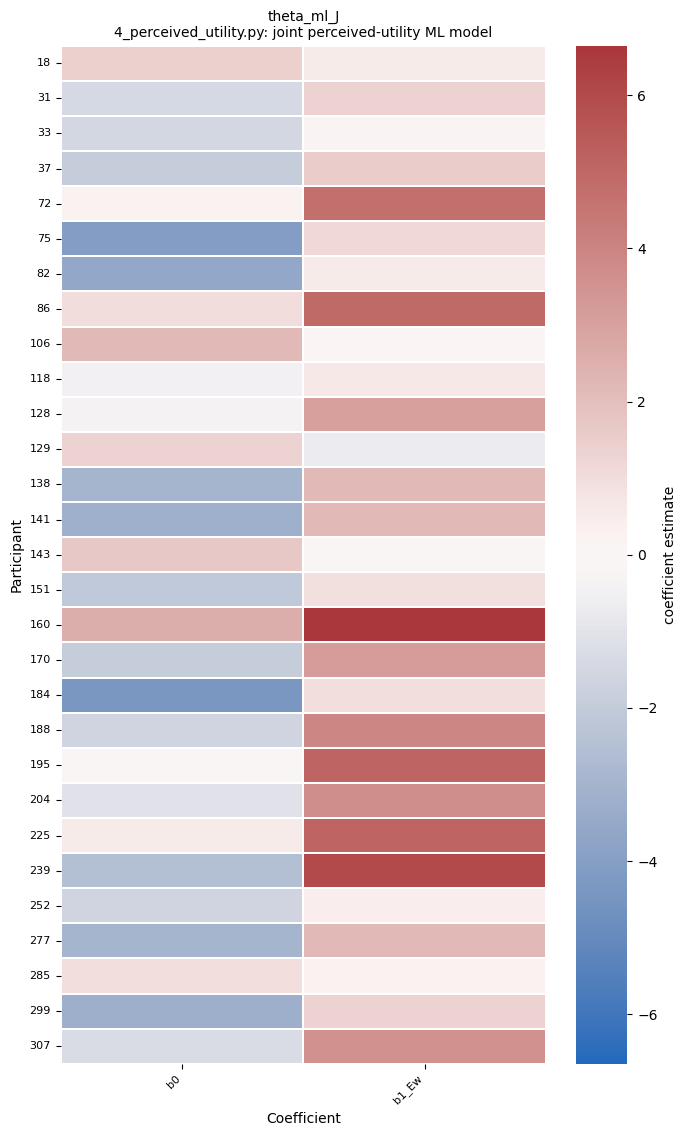

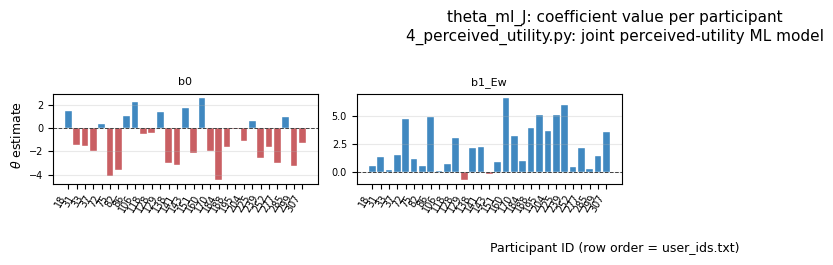

  plot theta_ml_U1: 29 participants x 3 coefficients


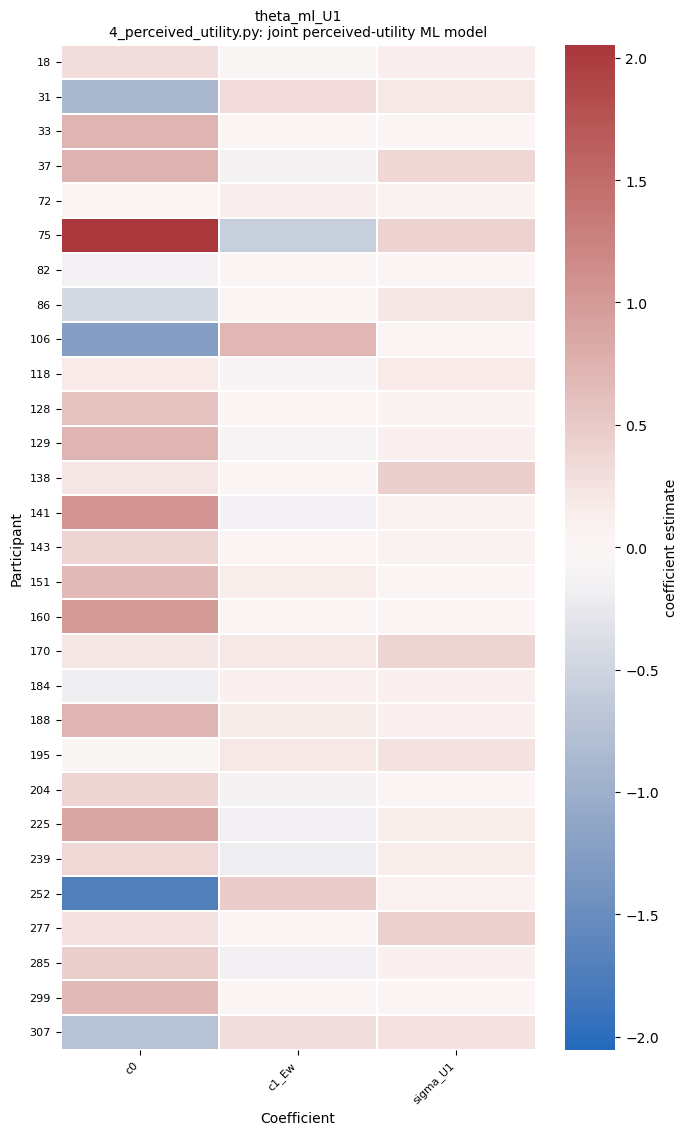

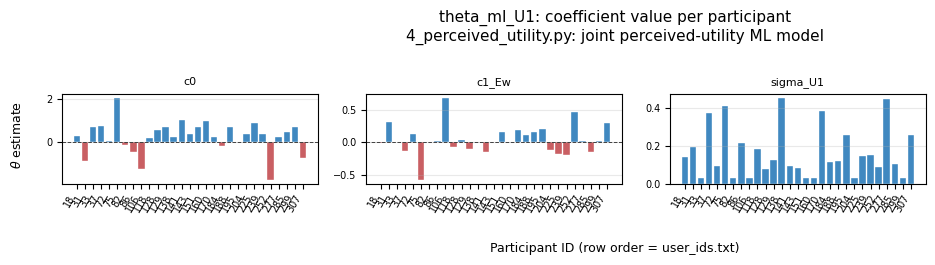

  plot theta_ml_U2: 29 participants x 3 coefficients


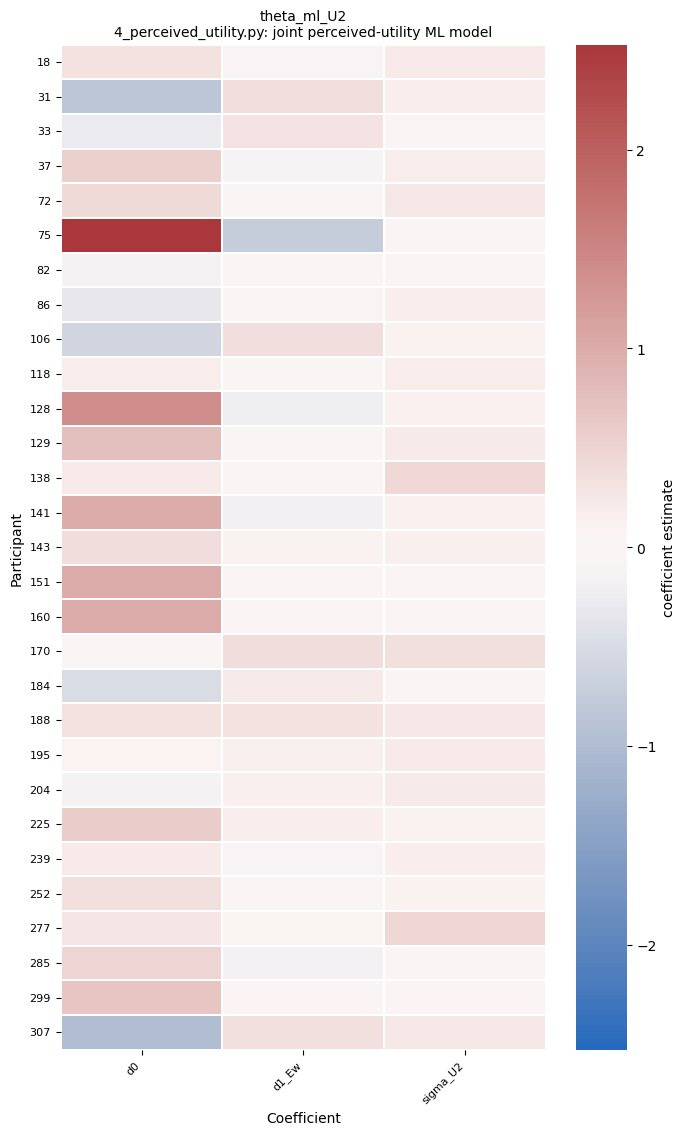

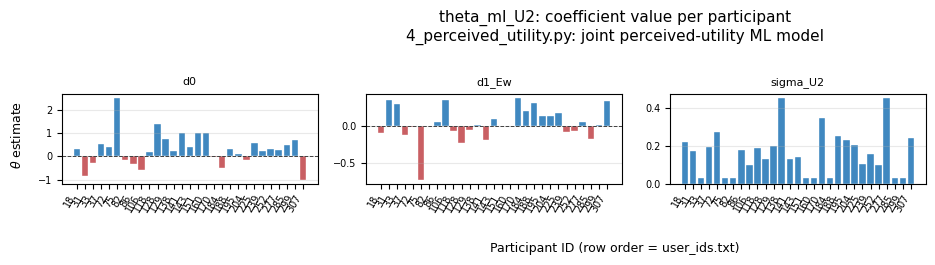

  plot theta_ml_PV: 29 participants x 14 coefficients


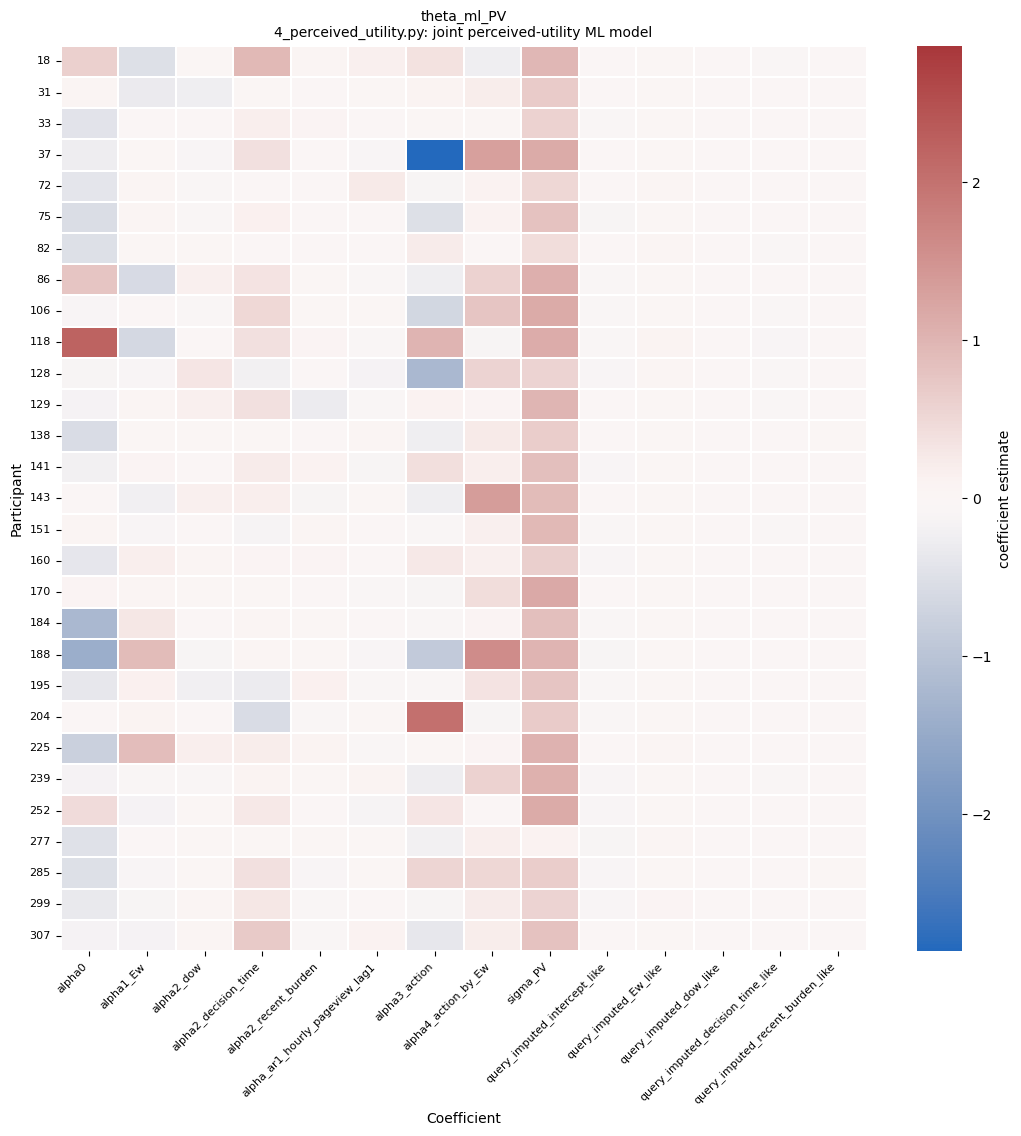

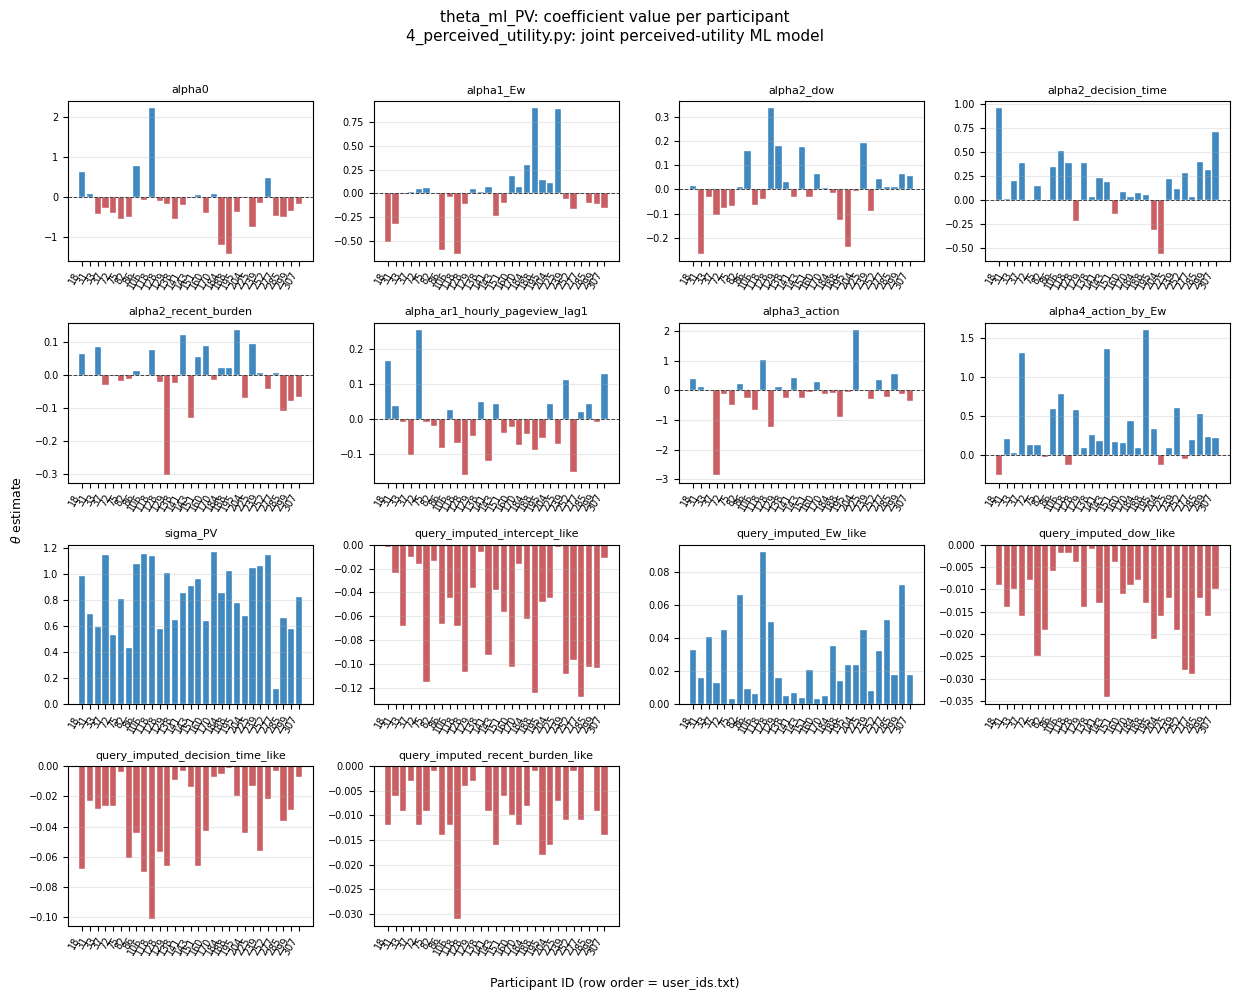

  plot theta_ml_FW: 29 participants x 13 coefficients


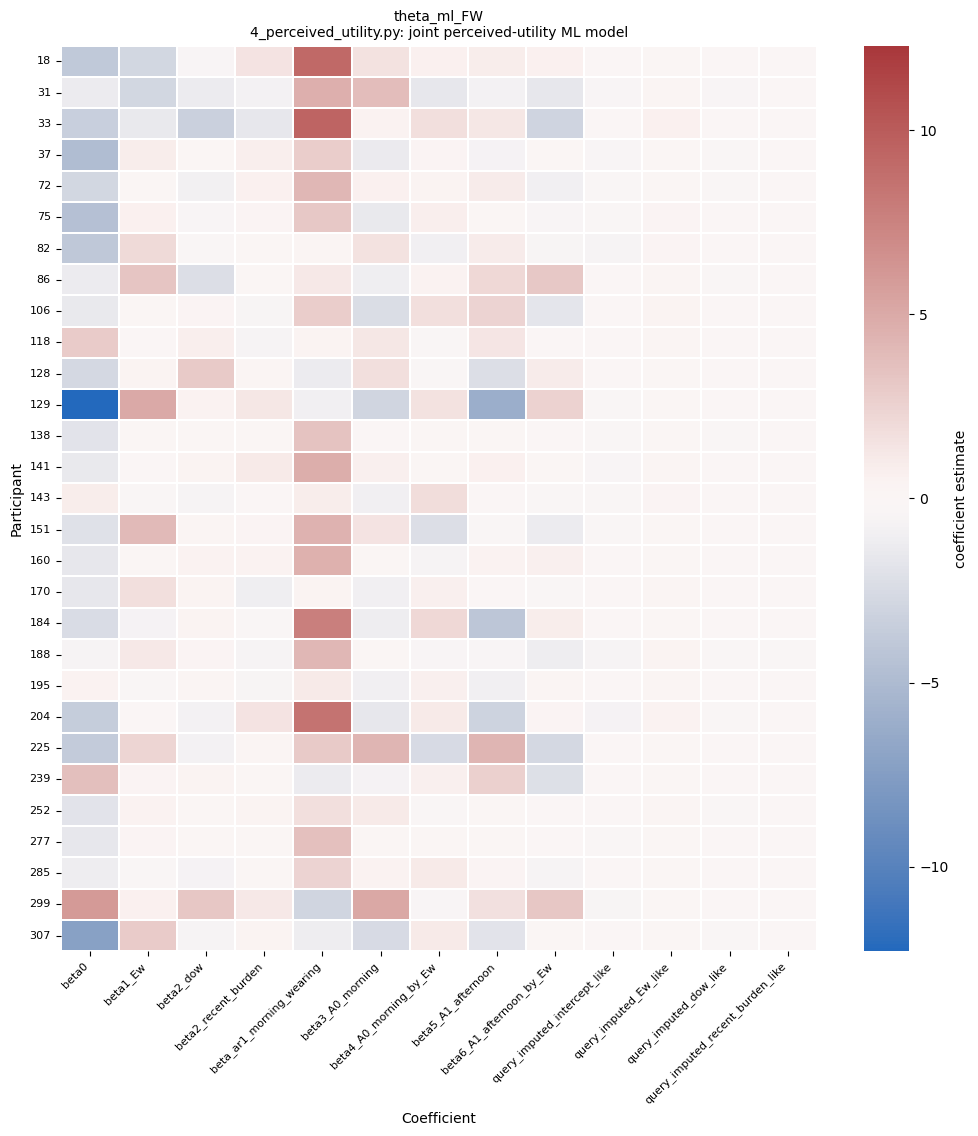

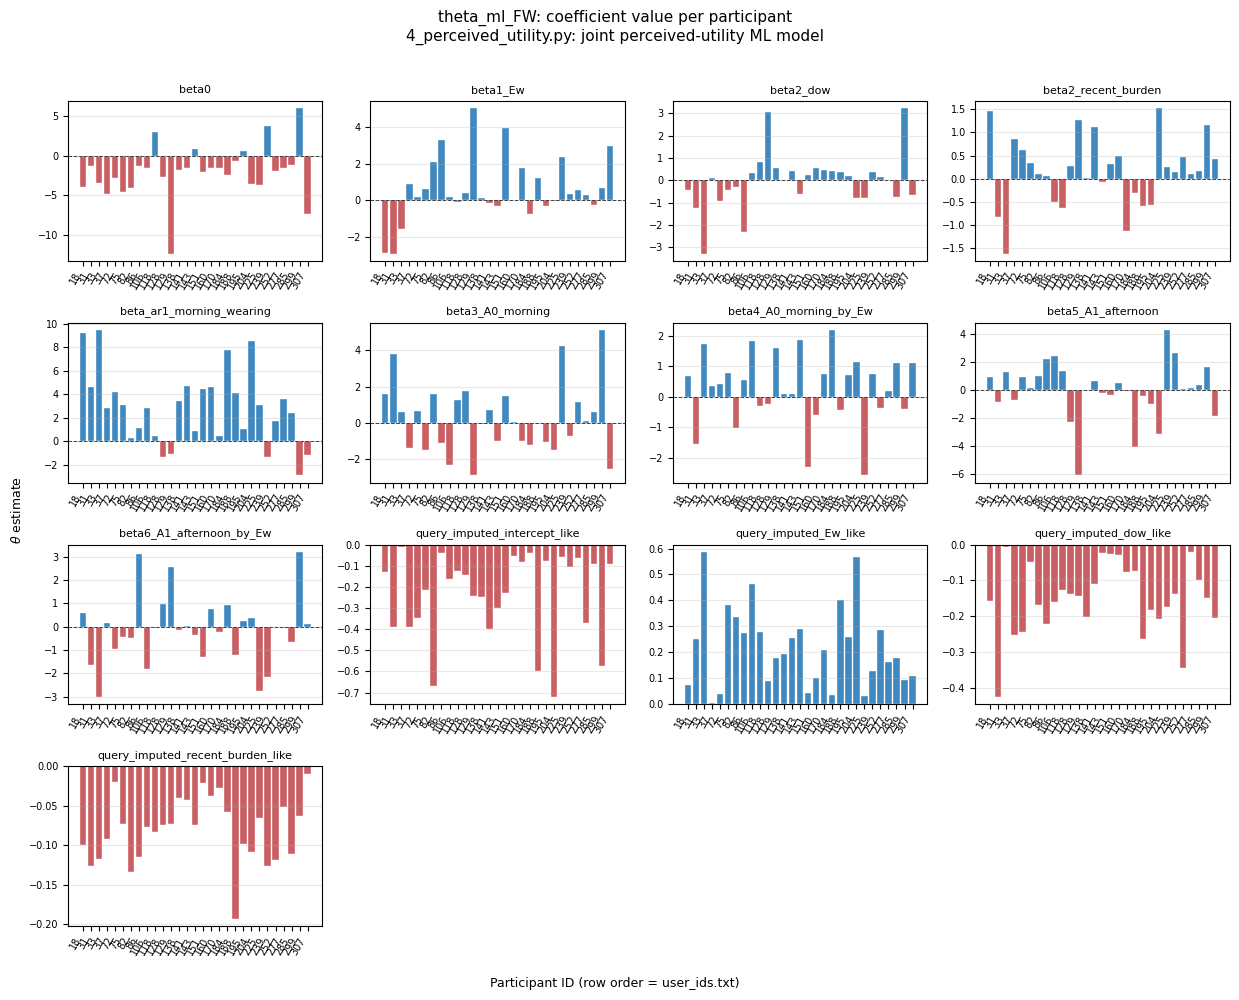

  plot theta_ml_PJ: 29 participants x 13 coefficients


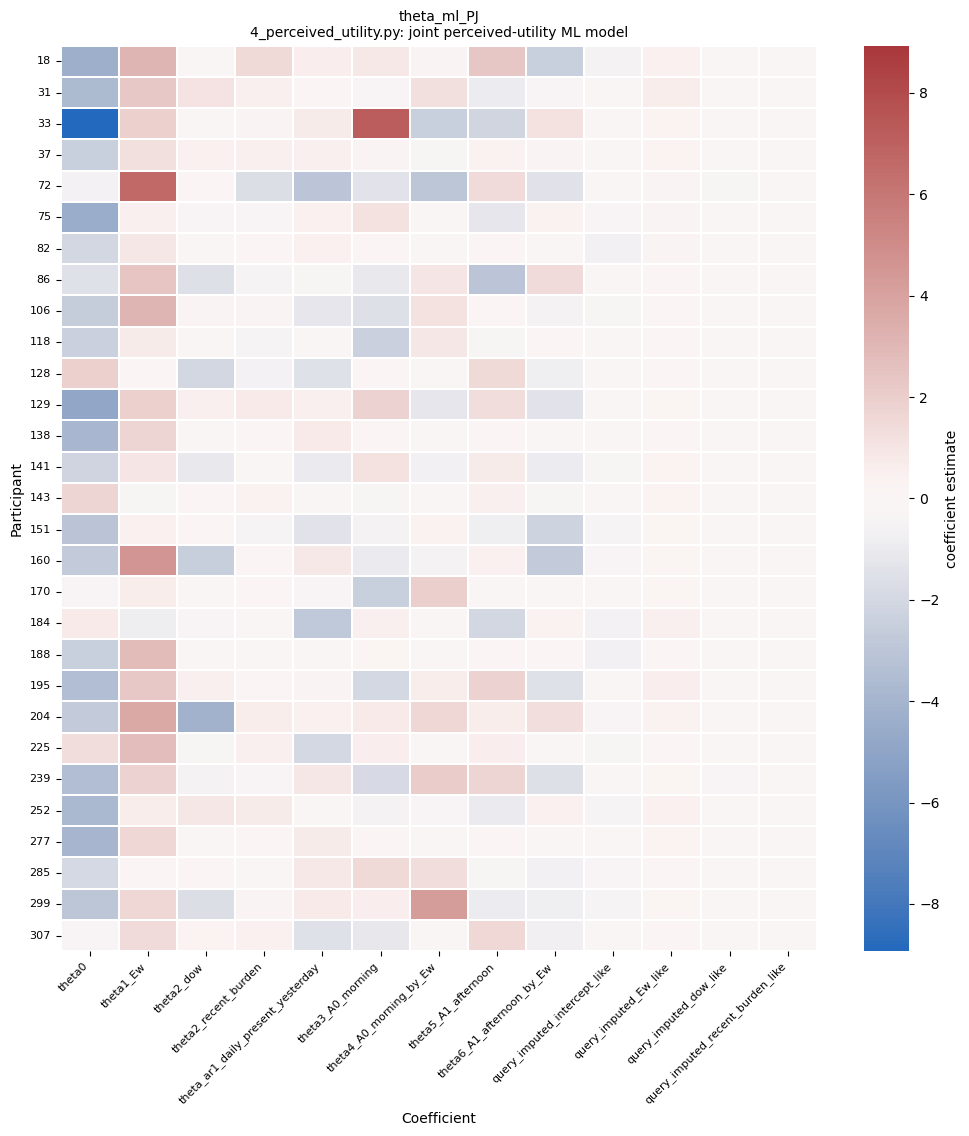

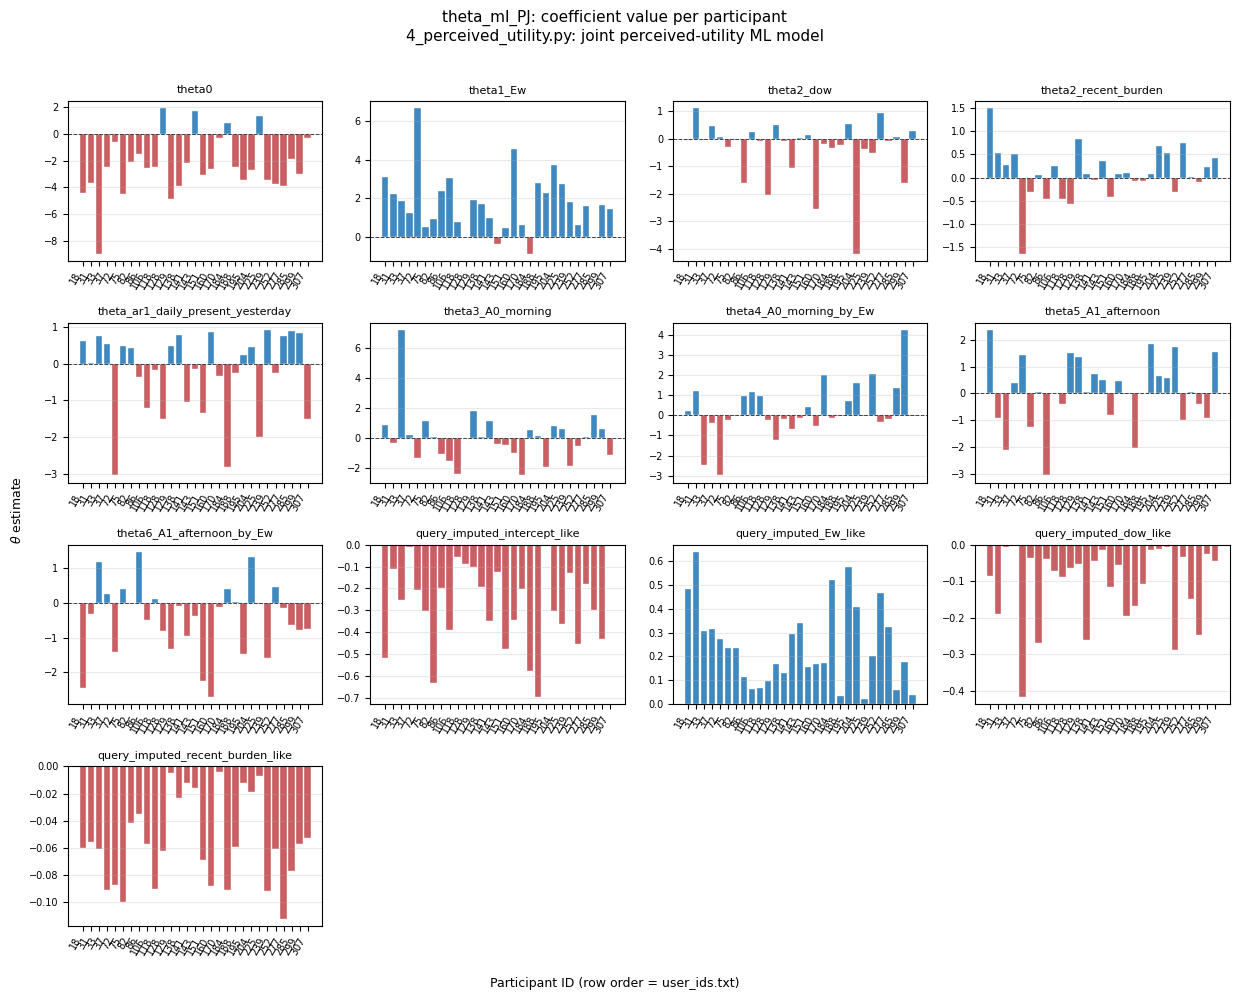


5_fit_vanilla_testbed.py: vanilla mediator/outcome models
  plot theta_prior2hour_step_count: 29 participants x 4 coefficients


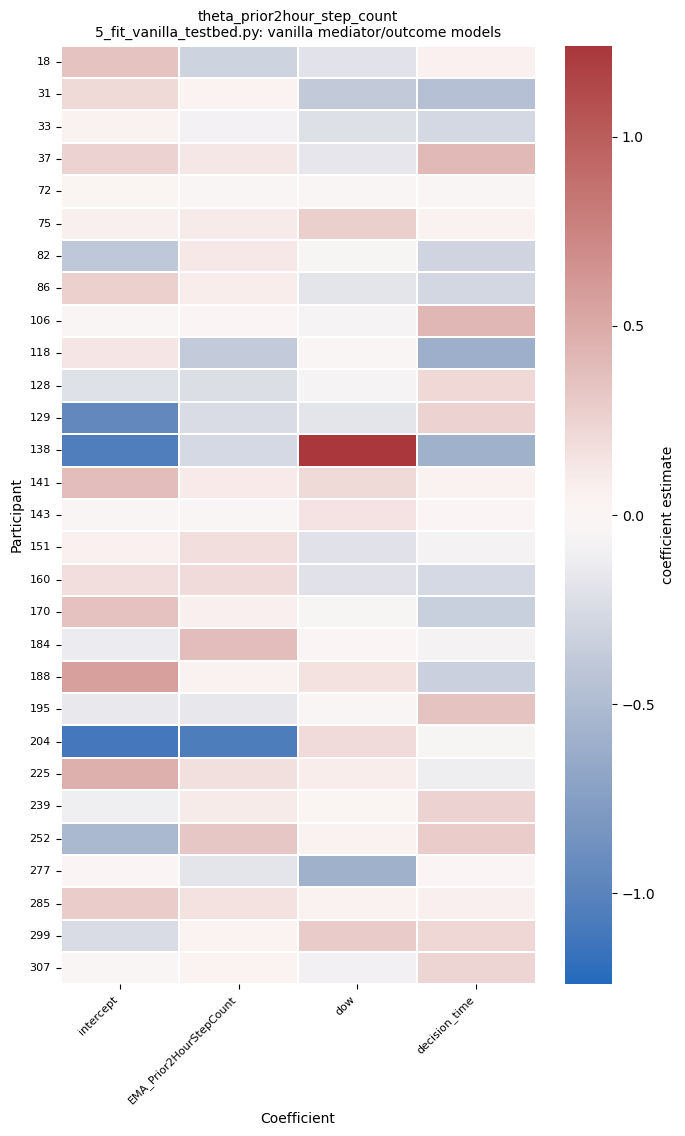

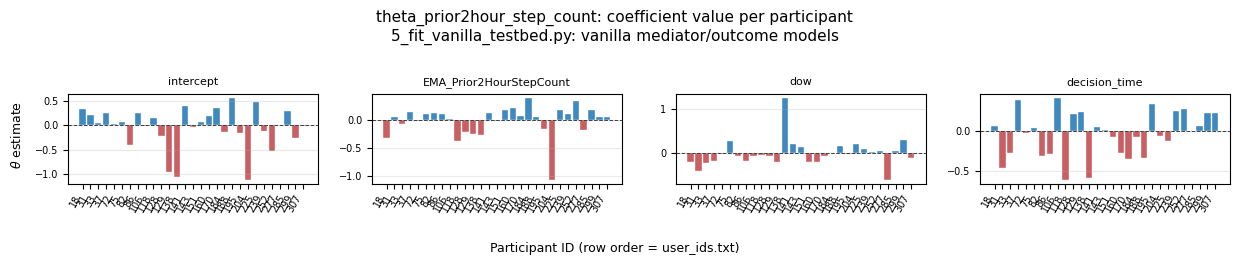

  plot theta_recorded_physical_activity: 29 participants x 3 coefficients


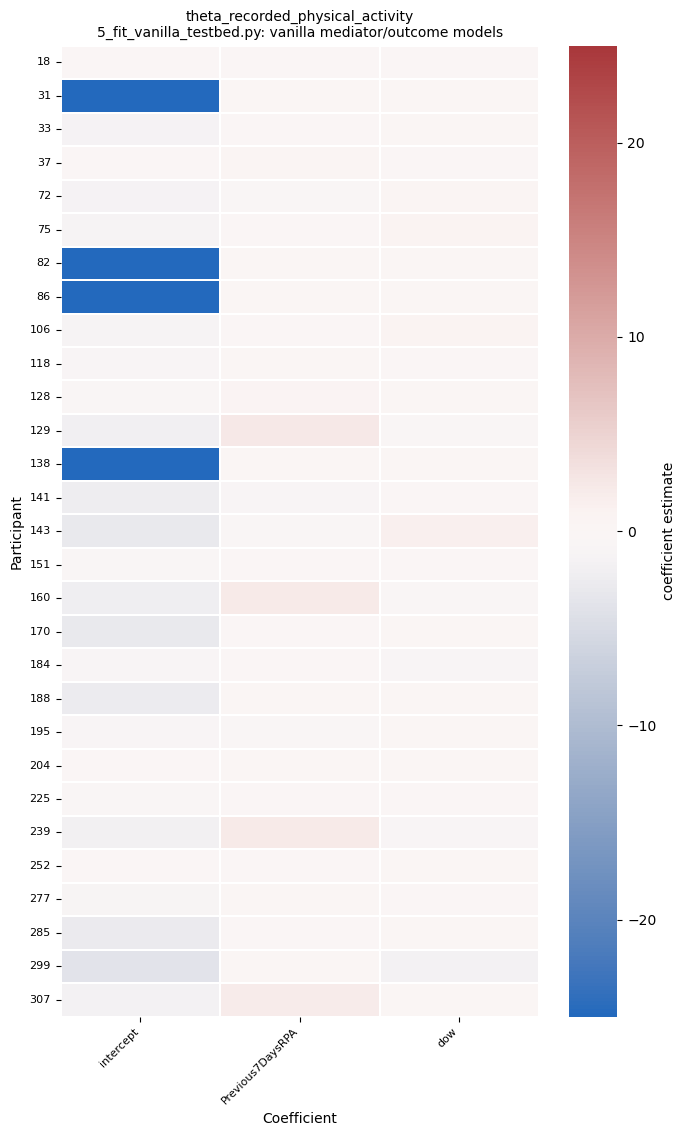

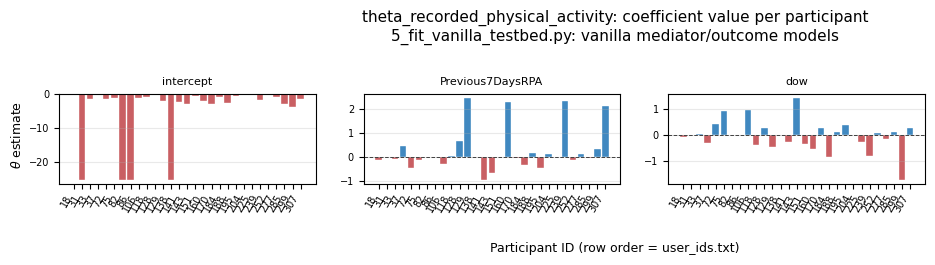

  plot theta_active_status: 29 participants x 3 coefficients


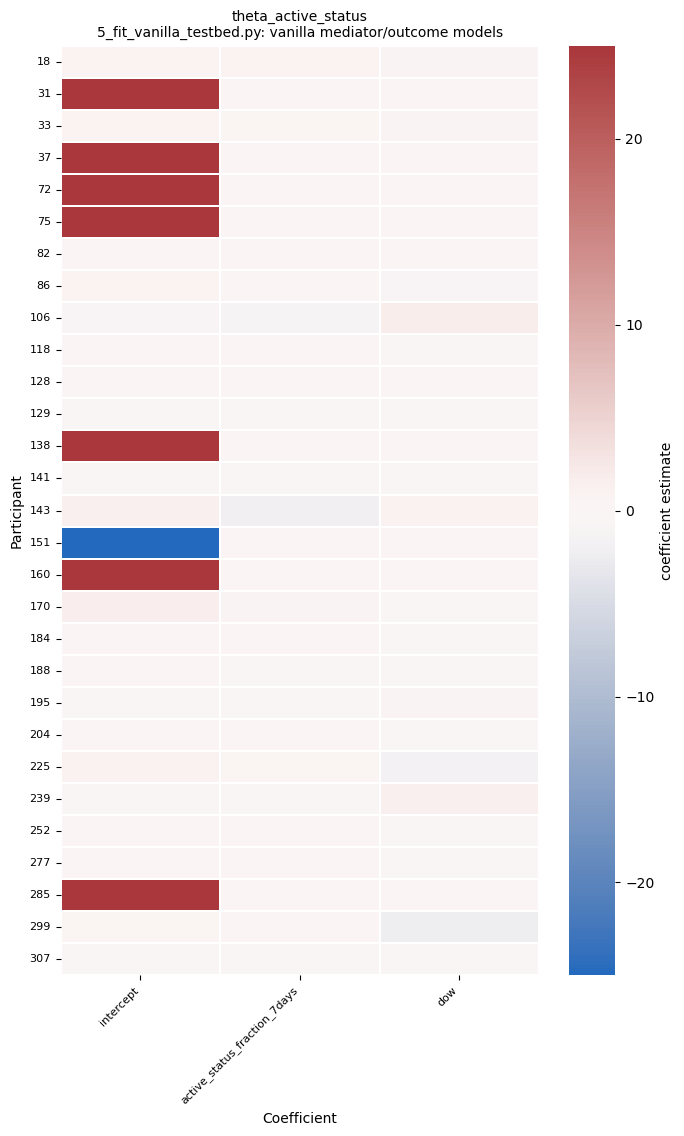

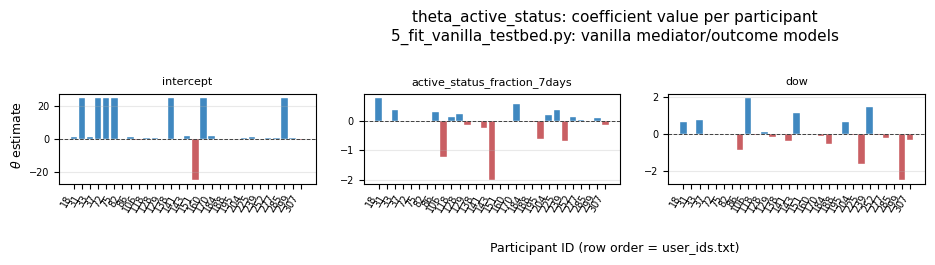

  plot theta_ws_interaction: 29 participants x 4 coefficients


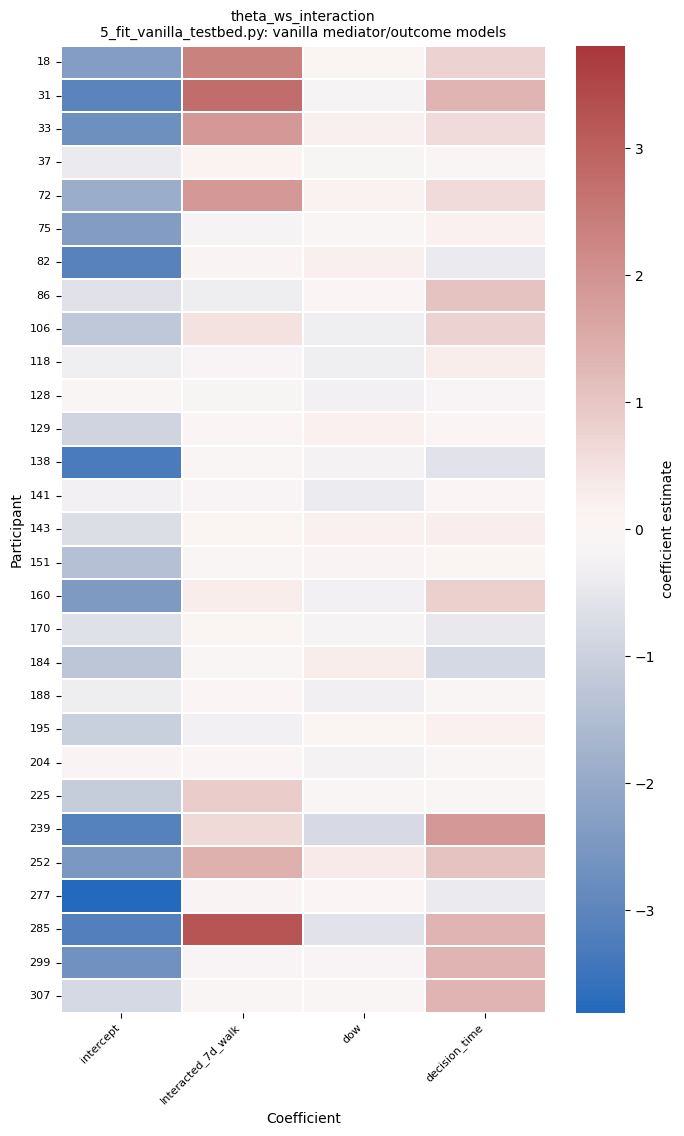

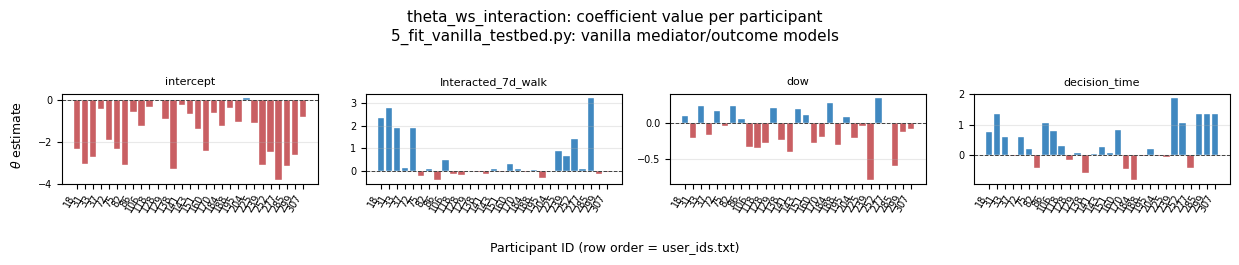

  plot theta_fourSC: 29 participants x 30 coefficients


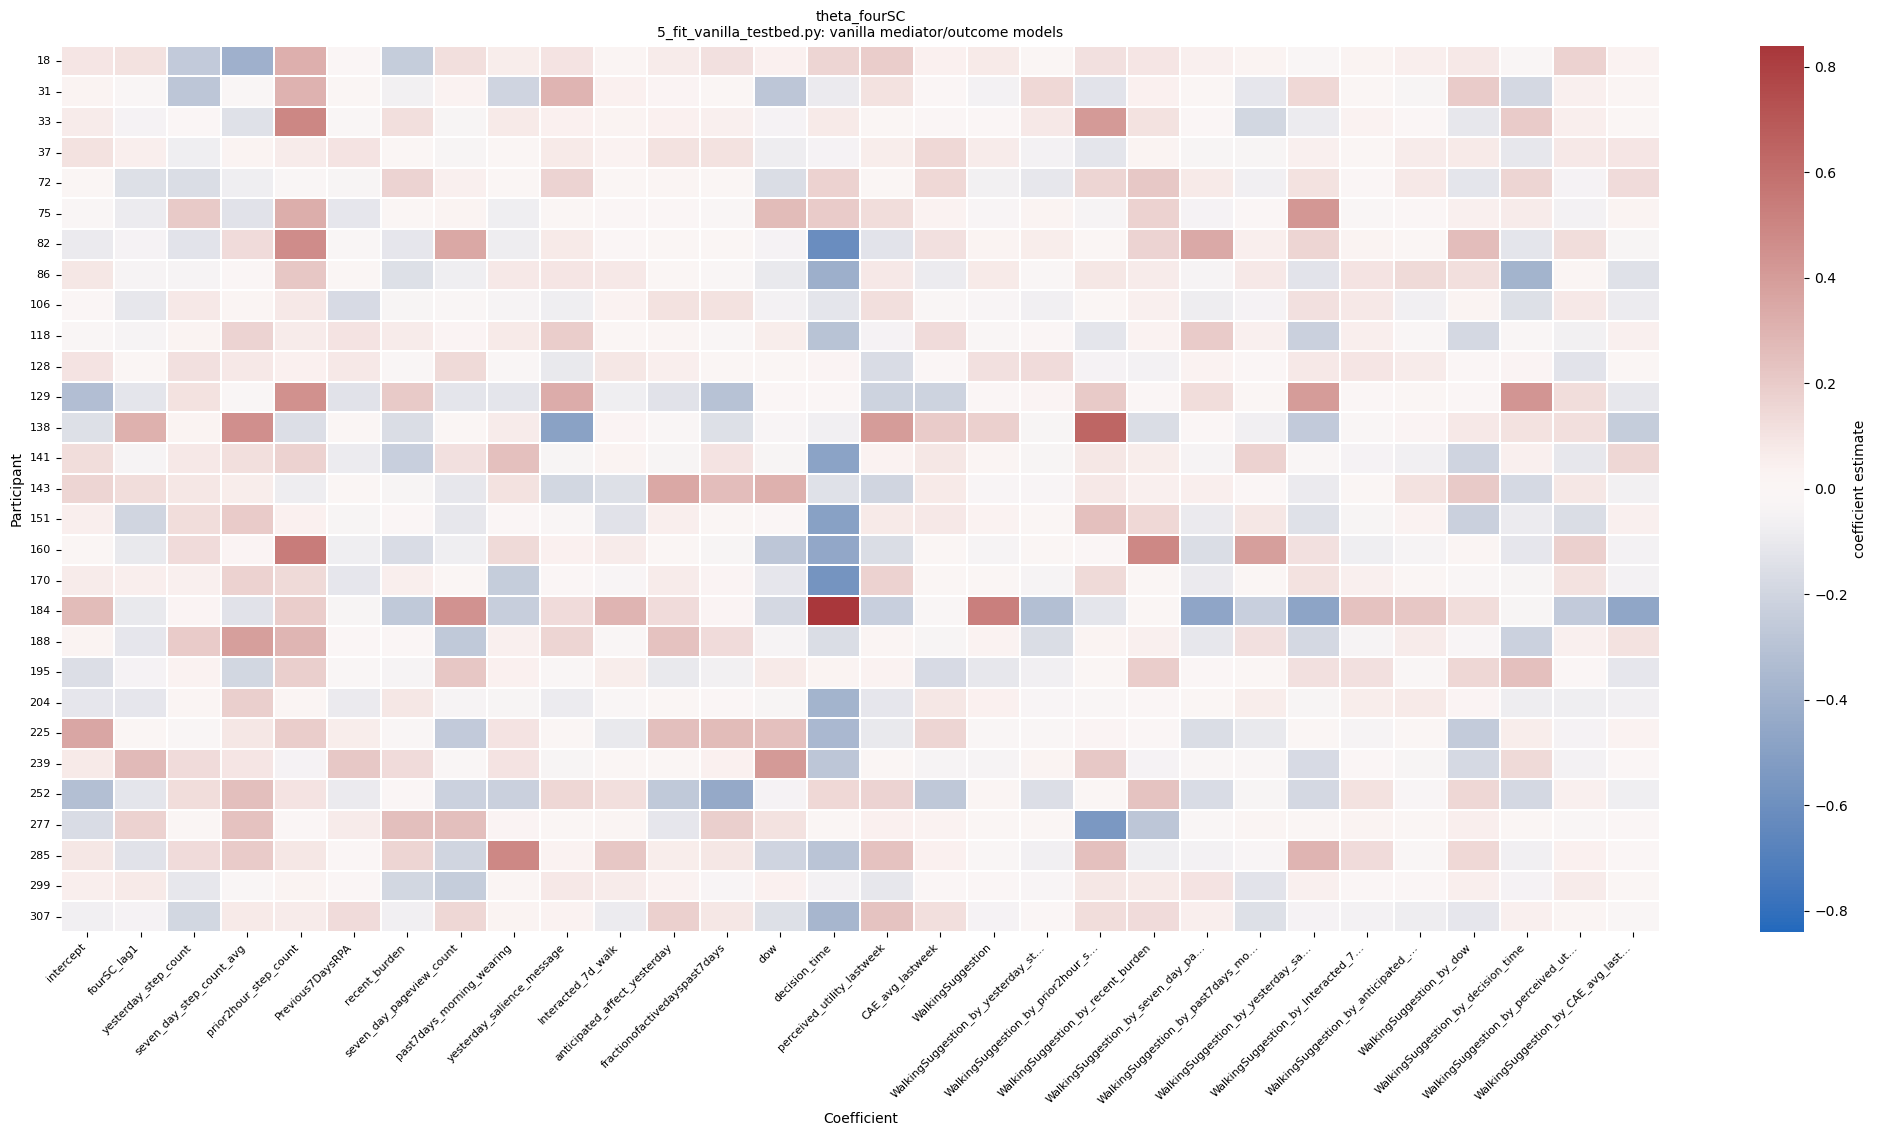

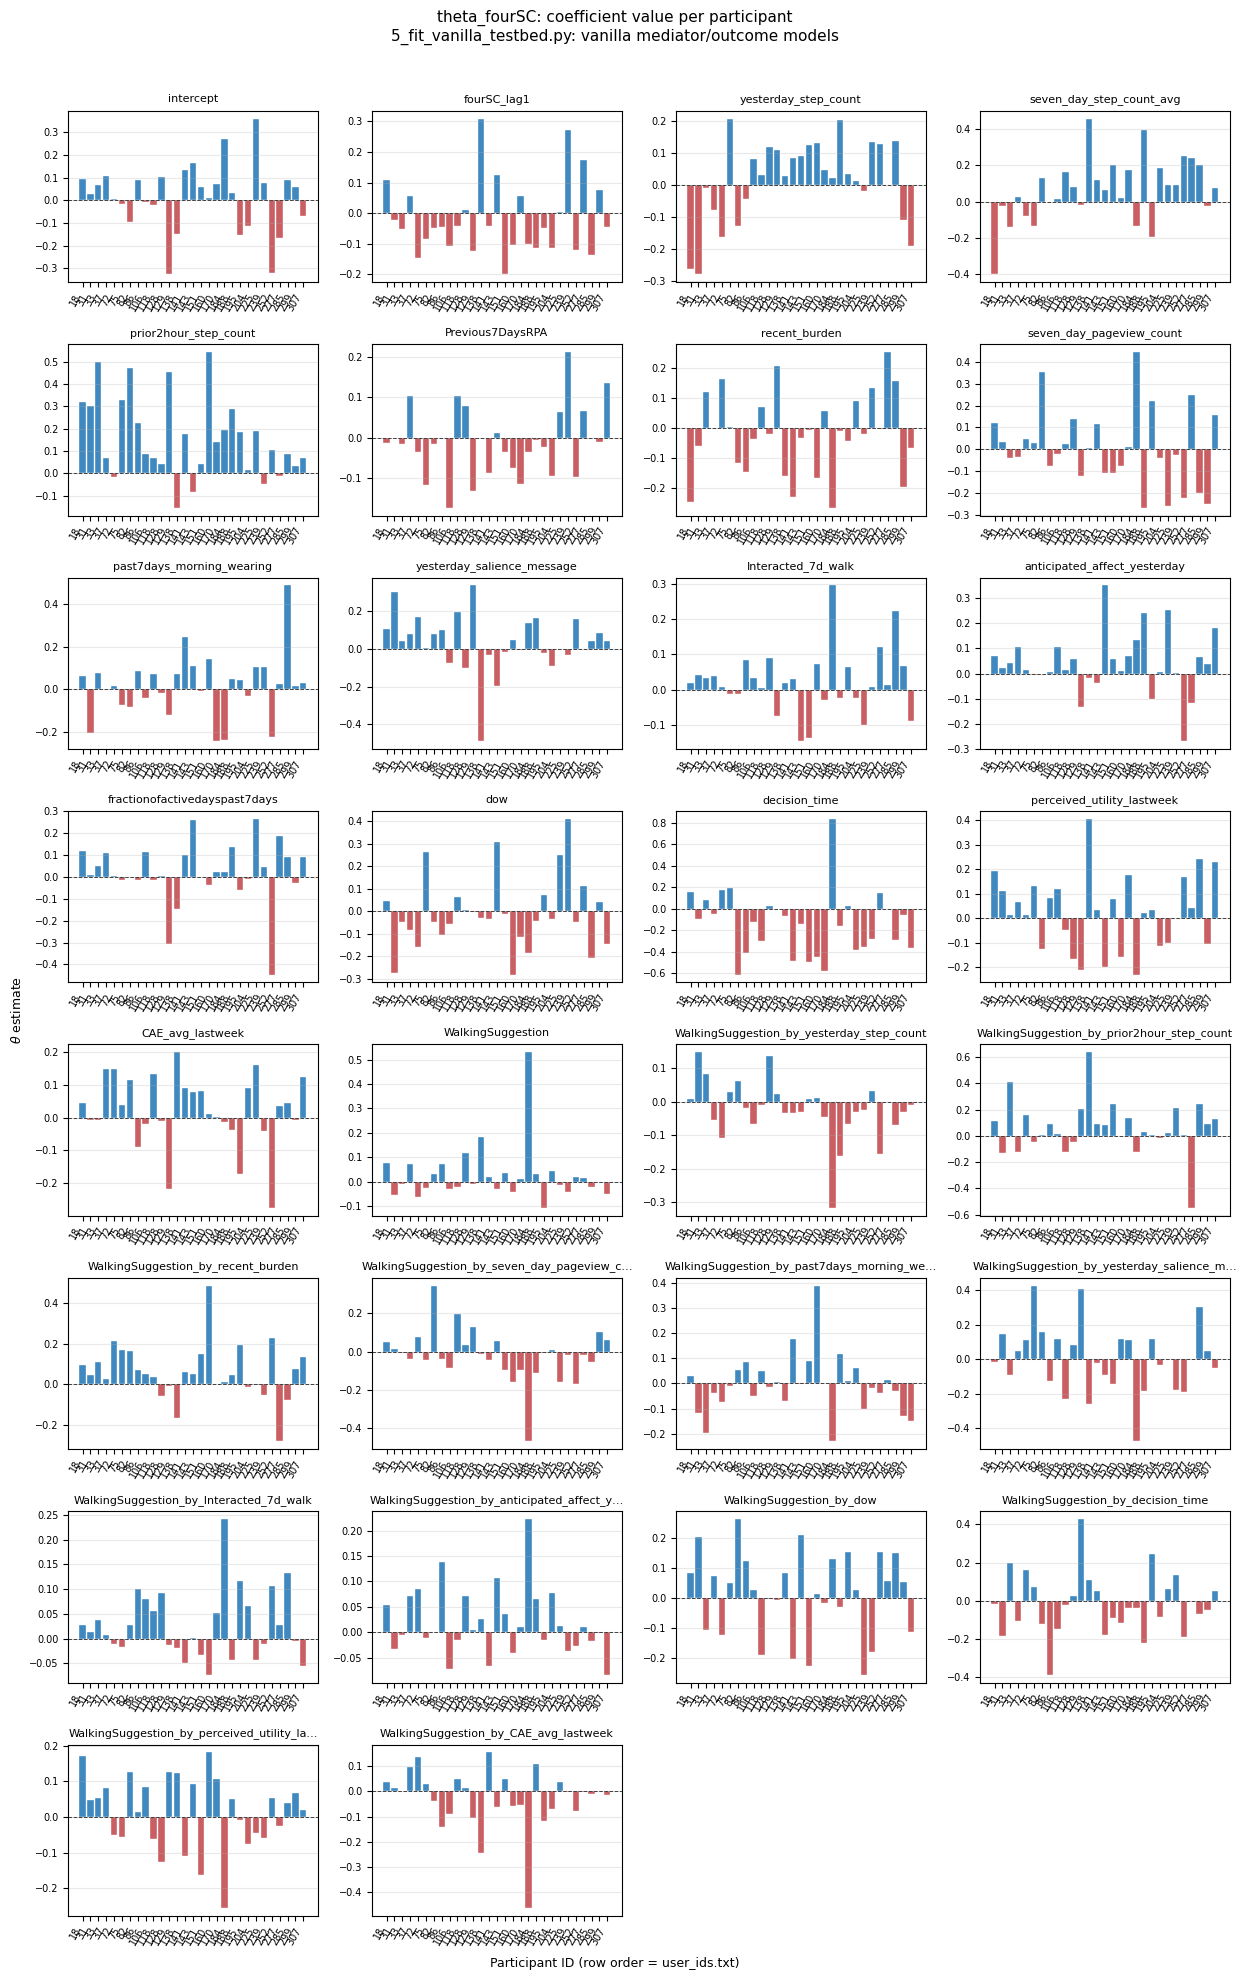

  plot theta_antic: 29 participants x 19 coefficients


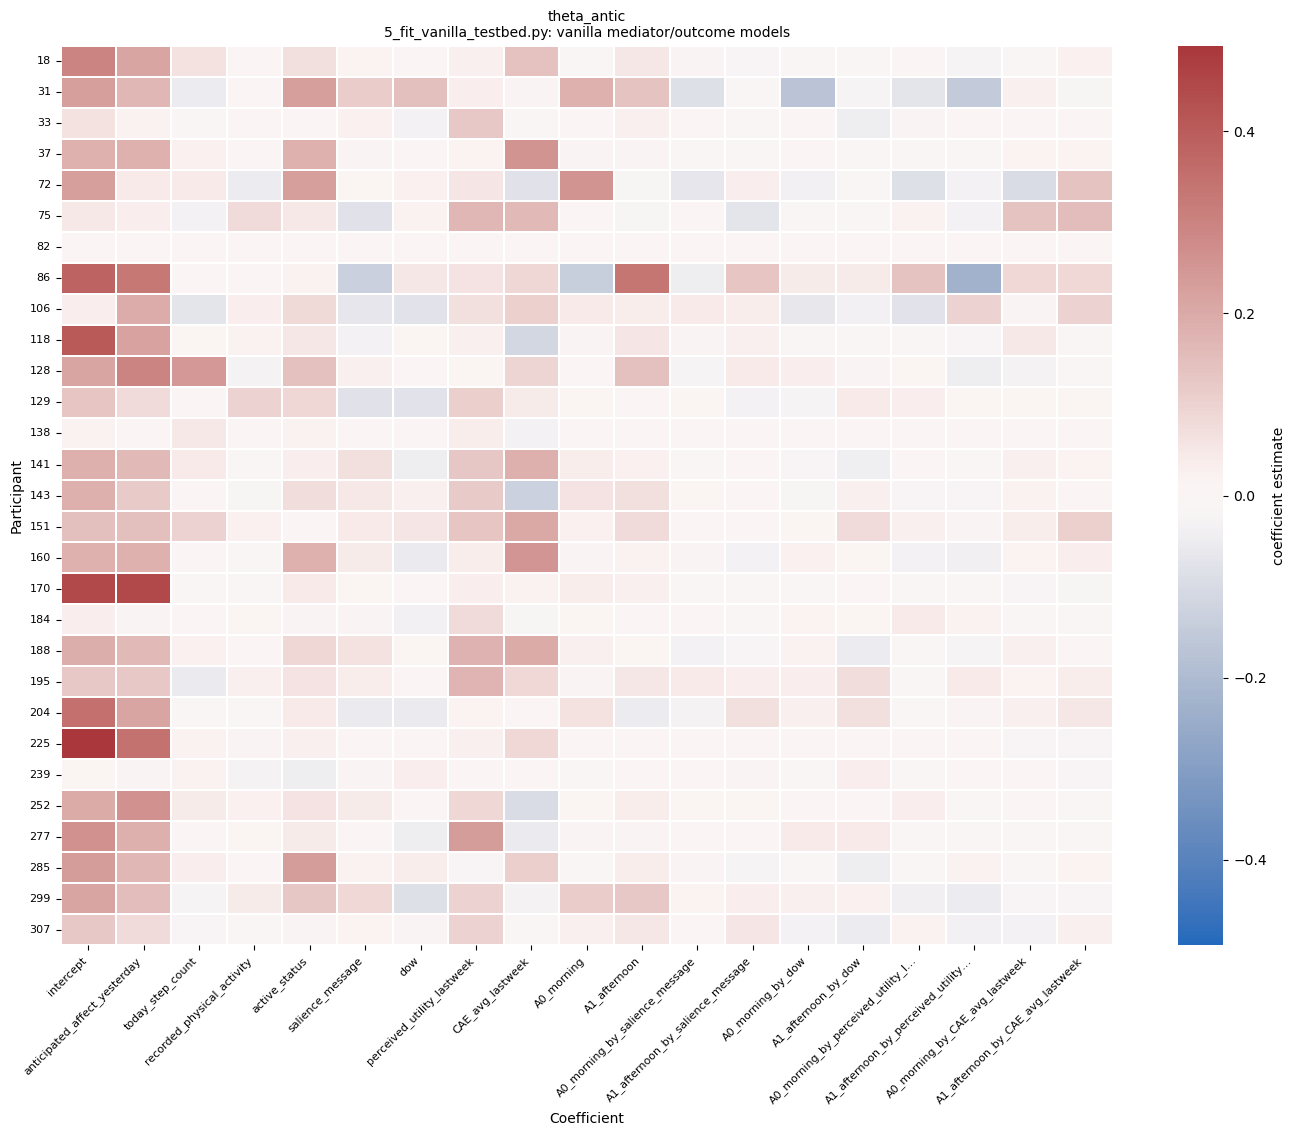

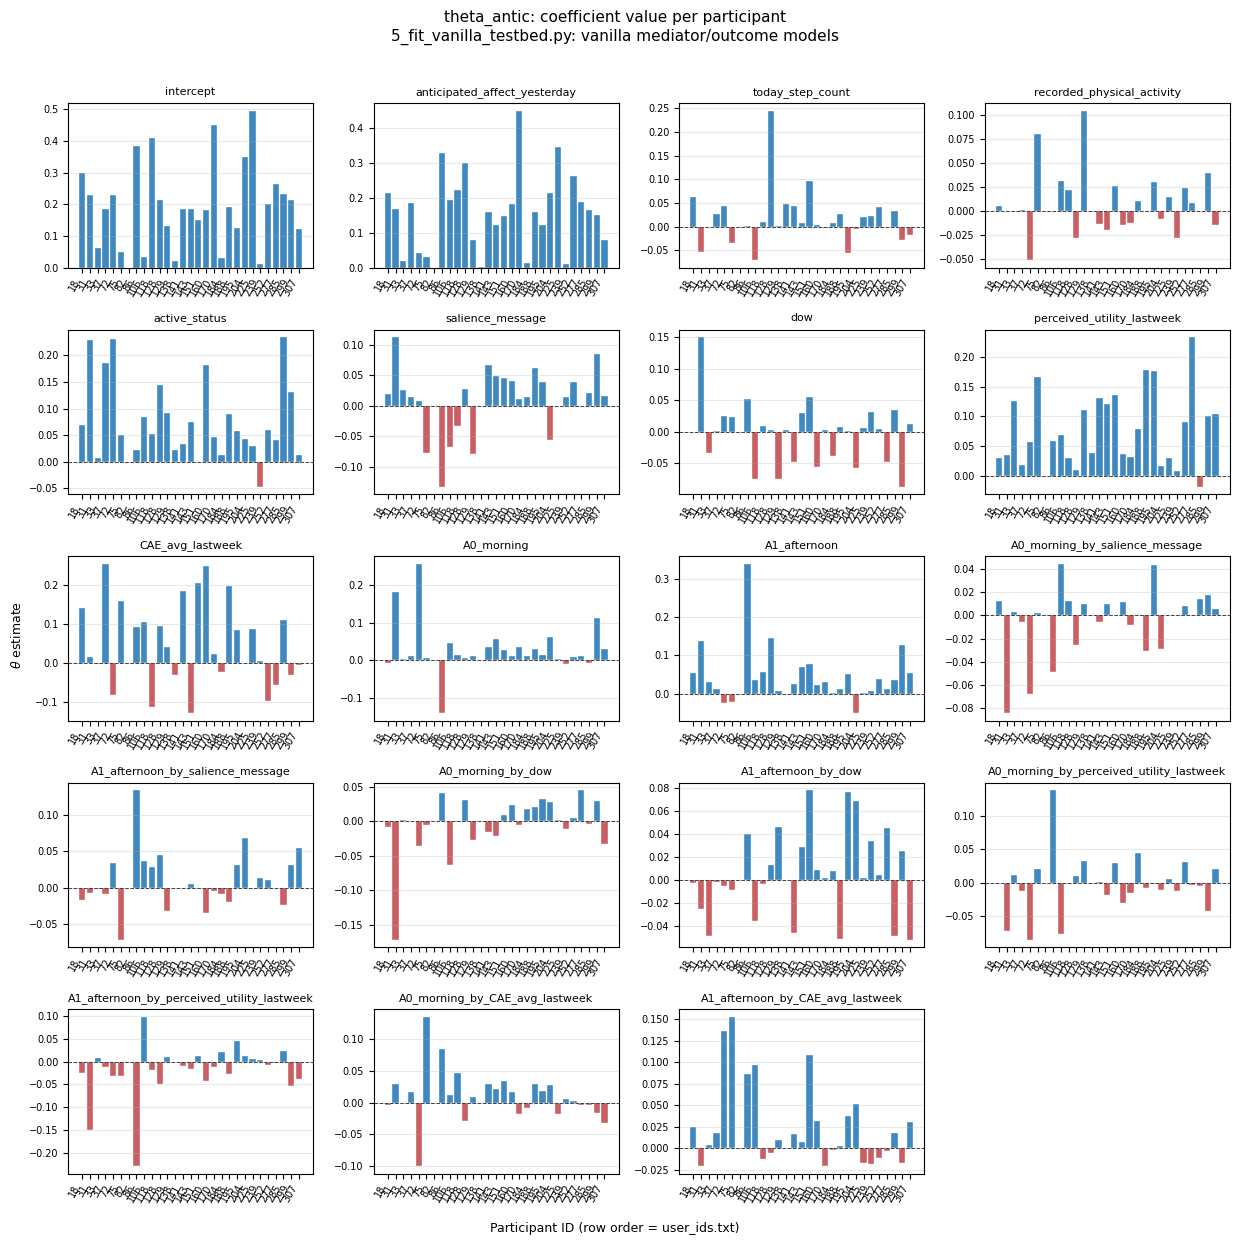

  plot theta_CAE: 29 participants x 24 coefficients


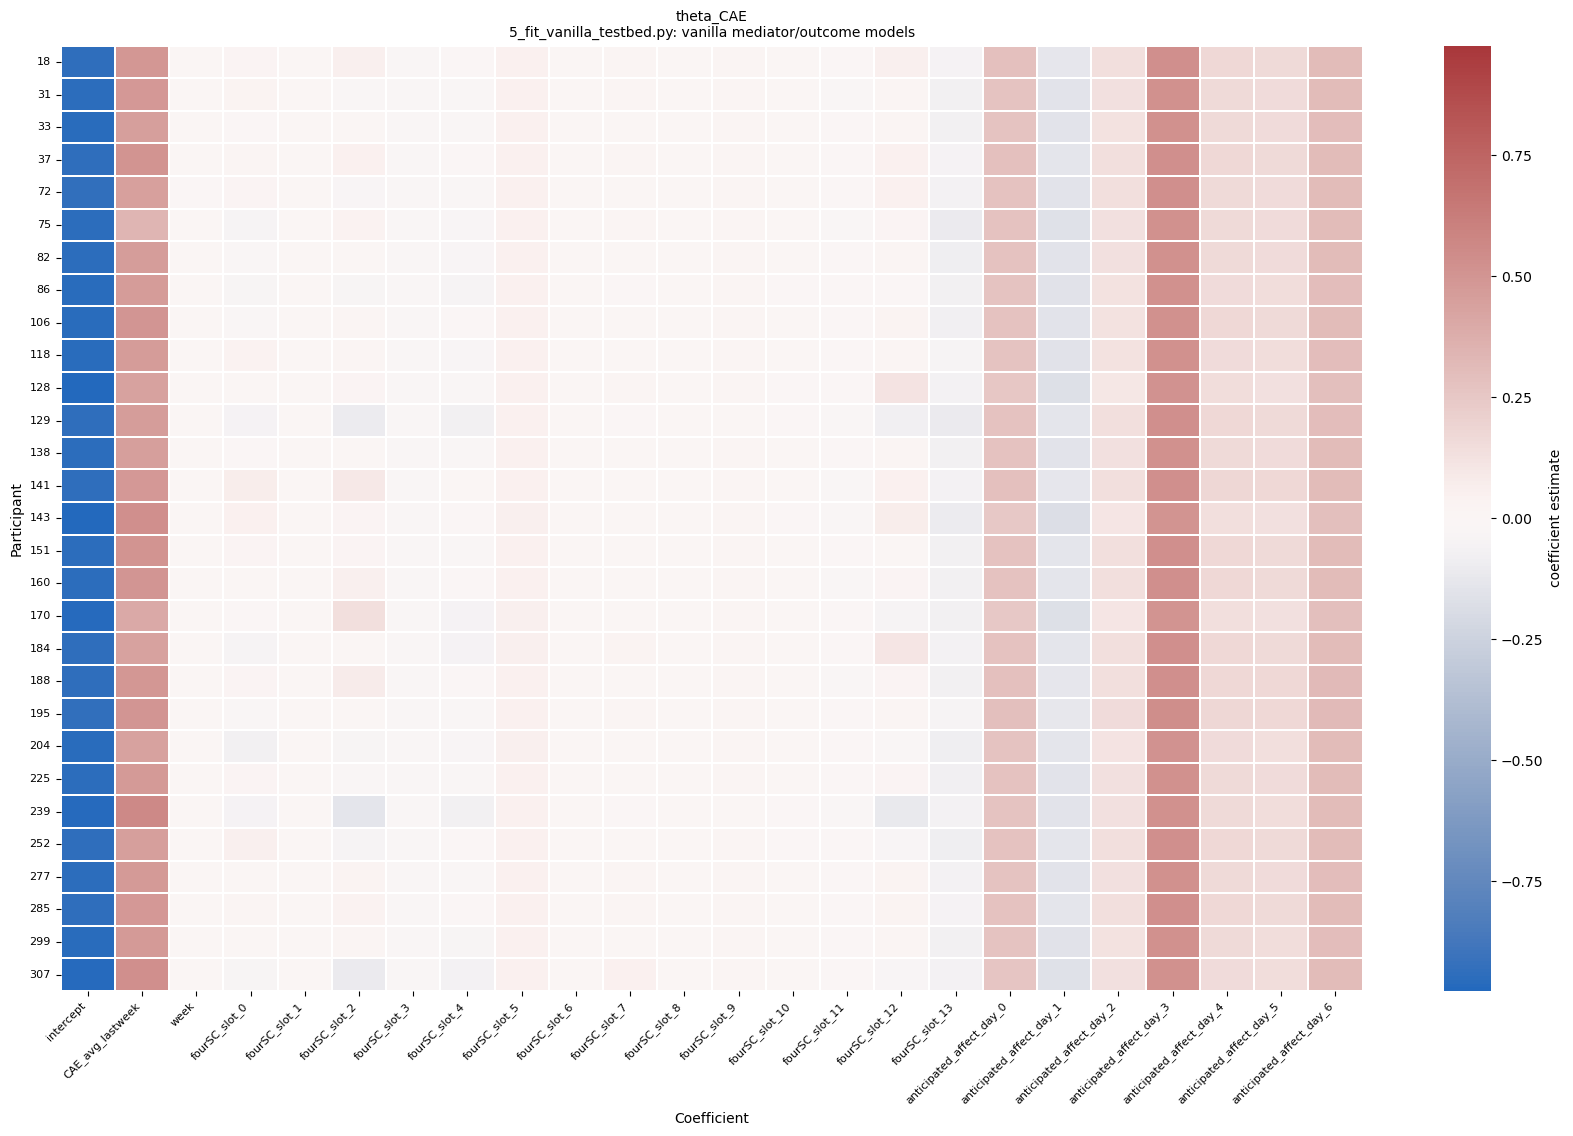

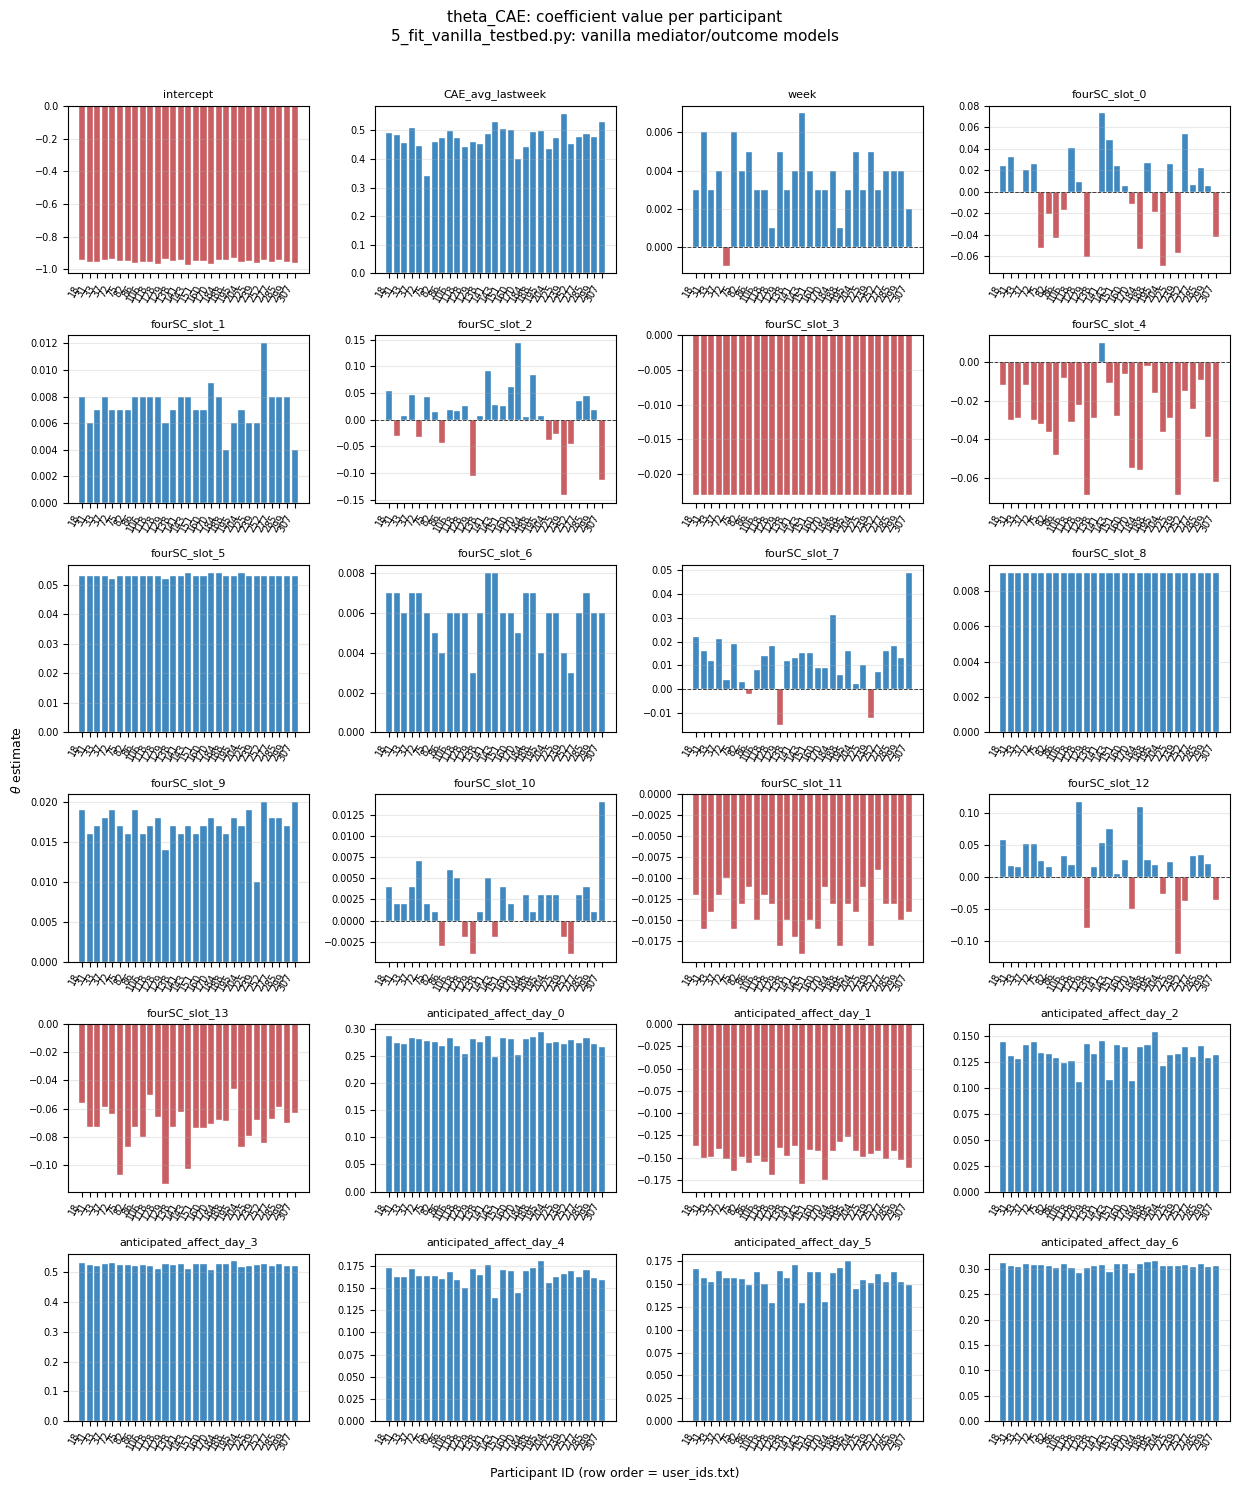

  plot theta_CAE_short_avg: 29 participants x 2 coefficients


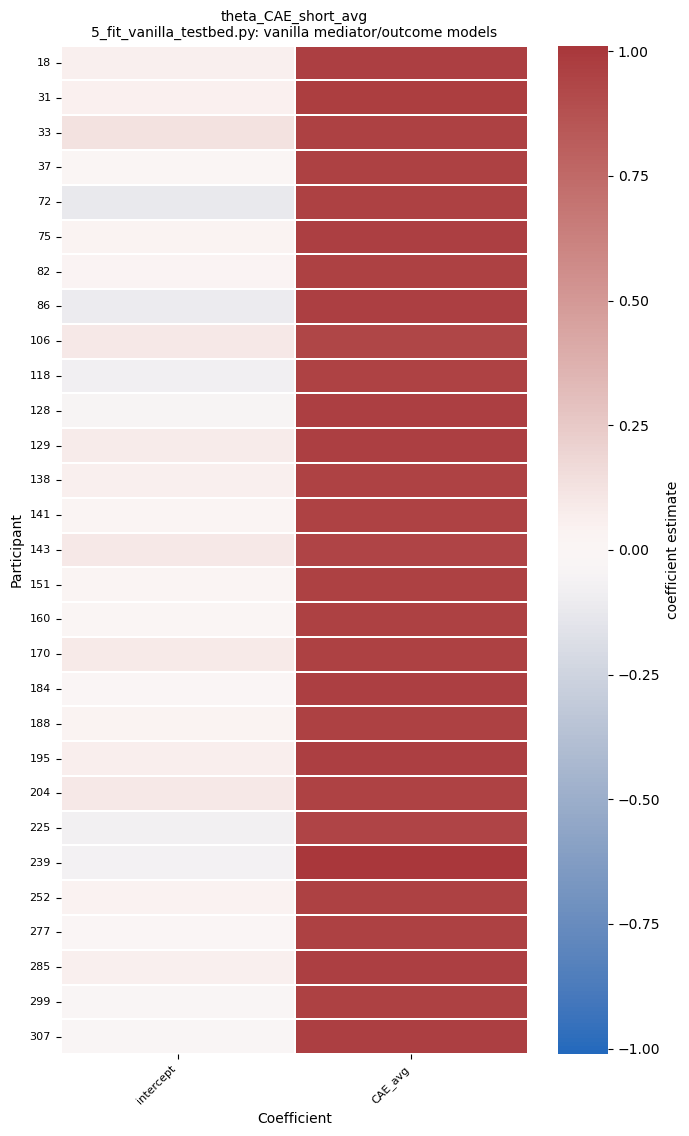

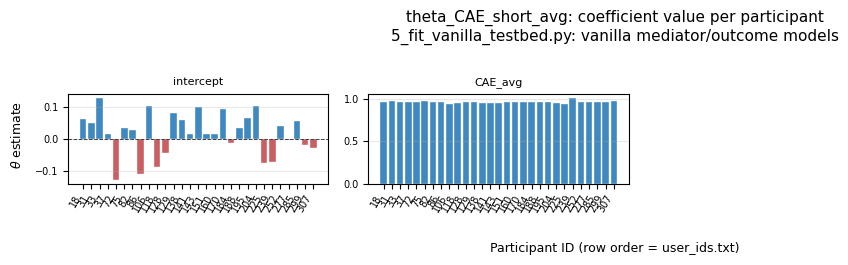

In [27]:
# Estimated coefficient diagnostics from `4_perceived_utility.py` and `5_fit_vanilla_testbed.py`.
#
# Each `theta_*` vector is loaded from `env_para_vanilla/params_env_{userid}.json`.
# Companion `{theta_key}_names` fields are used for readable coefficient labels when available.
# Heatmaps are centered at 0 so color shows direction; per-coefficient bar plots show magnitude by participant.

PERCEIVED_UTILITY_THETA_KEYS = [
    "theta_ml_Ew",
    "theta_ml_E1_prior",
    "theta_ml_J",
    "theta_ml_U1",
    "theta_ml_U2",
    "theta_ml_PV",
    "theta_ml_FW",
    "theta_ml_PJ",
]

VANILLA_TESTBED_THETA_KEYS = [
    "theta_prior2hour_step_count",
    "theta_recorded_physical_activity",
    "theta_active_status",
    "theta_ws_interaction",
    "theta_fourSC",
    "theta_antic",
    "theta_CAE",
    "theta_CAE_short_avg",
]

COEFFICIENT_GROUPS = {
    "4_perceived_utility.py: joint perceived-utility ML model": PERCEIVED_UTILITY_THETA_KEYS,
    "5_fit_vanilla_testbed.py: vanilla mediator/outcome models": VANILLA_TESTBED_THETA_KEYS,
}

PLOT_COEFFICIENT_HEATMAPS = True
PLOT_COEFFICIENT_BARS = True
PLOT_COEFFICIENT_HISTOGRAMS = False


def _load_params_json(uid):
    pth = Path(file_params_env_prefix + str(int(uid)) + ".json")
    if not pth.is_file():
        return None
    with open(pth, "r", encoding="utf-8") as f:
        return json.load(f)


def _fallback_coef_names(param_key: str, n_coef: int):
    return [f"{param_key}[{j}]" for j in range(n_coef)]


def load_theta_panel(param_key: str):
    """Return (matrix, coefficient_names), with rows aligned to `userid_all` and missing values as NaN."""
    rows = []
    names = None

    for uid in userid_all:
        p = _load_params_json(uid)
        if p is None or param_key not in p:
            rows.append(None)
            continue

        values = np.asarray(p[param_key], dtype=float).ravel()
        rows.append(values)

        candidate_names = p.get(f"{param_key}_names")
        if names is None and isinstance(candidate_names, list) and len(candidate_names) > 0:
            names = [str(x) for x in candidate_names]

    if all(r is None for r in rows):
        return None, None

    maxlen = max((r.size for r in rows if r is not None), default=0)
    if maxlen == 0:
        return None, None

    if names is None:
        names = _fallback_coef_names(param_key, maxlen)
    elif len(names) < maxlen:
        names = names + [f"extra_{j}" for j in range(len(names), maxlen)]
    elif len(names) > maxlen:
        names = names[:maxlen]

    mat = np.full((len(userid_all), maxlen), np.nan, dtype=float)
    for i, r in enumerate(rows):
        if r is not None:
            mat[i, : r.size] = r

    return mat, names


def _short_label(text: str, max_chars: int = 34):
    text = str(text)
    return text if len(text) <= max_chars else text[: max_chars - 1] + "…"


def _finite_symmetric_limit(M: np.ndarray):
    finite = np.asarray(M, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return None
    vmax = float(np.nanmax(np.abs(finite)))
    if not np.isfinite(vmax) or vmax == 0.0:
        vmax = 1.0
    return vmax


def plot_theta_heatmap(param_key: str, M: np.ndarray, coef_names, *, source_label: str):
    if M is None or M.size == 0:
        print(f"(skip heatmap {param_key}: no data)")
        return

    vmax = _finite_symmetric_limit(M)
    if vmax is None:
        print(f"(skip heatmap {param_key}: no finite values)")
        return

    n_users, n_coef = M.shape
    fig_w = max(7.0, min(22.0, 0.62 * n_coef + 2.2))
    fig_h = max(3.2, min(18.0, 0.34 * n_users + 1.6))
    fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h))

    sns.heatmap(
        M,
        ax=ax,
        cmap="vlag",
        norm=TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax),
        linewidths=0.35,
        linecolor="white",
        cbar_kws={"label": "coefficient estimate"},
    )
    ax.set_title(f"{param_key}\n{source_label}", fontsize=10)
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Participant")
    ax.set_xticklabels([_short_label(n) for n in coef_names], rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels([str(int(u)) for u in userid_all], rotation=0, fontsize=8)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_theta_bars(param_key: str, M: np.ndarray, coef_names, *, source_label: str, max_cols: int = 4):
    """For each coefficient: one bar per participant, colored by sign."""
    if M is None or M.size == 0:
        print(f"(skip bar {param_key}: no data)")
        return

    n_coef = M.shape[1]
    n_rows = int(math.ceil(n_coef / max_cols))
    fig, axes = plt.subplots(
        n_rows,
        max_cols,
        figsize=(3.15 * max_cols, 2.45 * n_rows),
        squeeze=False,
    )
    axes = np.asarray(axes).reshape(-1)
    x = np.arange(len(userid_all))
    labels = [str(int(u)) for u in userid_all]

    for j in range(n_coef):
        ax = axes[j]
        y = M[:, j]
        if not np.any(np.isfinite(y)):
            ax.set_visible(False)
            continue

        colors = np.where(np.nan_to_num(y, nan=0.0) >= 0.0, "#2b7bba", "#c44e52")
        ax.bar(x, y, color=colors, alpha=0.9, edgecolor="white", linewidth=0.3)
        ax.axhline(0.0, color="0.25", linewidth=0.7, linestyle="--")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
        ax.set_title(_short_label(coef_names[j], max_chars=42), fontsize=8)
        ax.tick_params(axis="y", labelsize=7)
        ax.grid(True, axis="y", alpha=0.28)

    for k in range(n_coef, axes.size):
        axes[k].set_visible(False)

    fig.suptitle(f"{param_key}: coefficient value per participant\n{source_label}", fontsize=11, y=1.01)
    fig.supxlabel("Participant ID (row order = user_ids.txt)", fontsize=9)
    fig.supylabel(r"$\theta$ estimate", fontsize=9)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


def plot_theta_histograms(param_key: str, M: np.ndarray, coef_names, *, source_label: str, max_cols: int = 6, n_bins: int = 20):
    if M is None or M.size == 0:
        print(f"(skip histogram {param_key}: no data)")
        return

    n_coef = M.shape[1]
    n_rows = int(math.ceil(n_coef / max_cols))
    fig, axes = plt.subplots(
        n_rows,
        max_cols,
        figsize=(2.45 * max_cols, 2.05 * n_rows),
        squeeze=False,
    )
    axes = np.asarray(axes).reshape(-1)

    for j in range(n_coef):
        ax = axes[j]
        x = M[:, j]
        x = x[np.isfinite(x)]
        if x.size == 0:
            ax.set_visible(False)
            continue
        ax.hist(x, bins=n_bins, alpha=0.78, color="#4c78a8", edgecolor="white")
        ax.axvline(0.0, color="0.25", linewidth=0.7, linestyle="--")
        ax.set_title(_short_label(coef_names[j], max_chars=34), fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)

    for k in range(n_coef, axes.size):
        axes[k].set_visible(False)

    fig.suptitle(f"{param_key}: histograms across participants\n{source_label}", fontsize=11, y=1.01)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


_found_any = False
for _source_label, _theta_keys in COEFFICIENT_GROUPS.items():
    print("\n" + _source_label)
    for _key in _theta_keys:
        _M, _names = load_theta_panel(_key)
        if _M is None:
            print(f"  skip {_key}: not found in params_env_*.json")
            continue

        _found_any = True
        print(f"  plot {_key}: {_M.shape[0]} participants x {_M.shape[1]} coefficients")
        if PLOT_COEFFICIENT_HEATMAPS:
            plot_theta_heatmap(_key, _M, _names, source_label=_source_label)
        if PLOT_COEFFICIENT_BARS:
            plot_theta_bars(_key, _M, _names, source_label=_source_label)
        if PLOT_COEFFICIENT_HISTOGRAMS:
            plot_theta_histograms(_key, _M, _names, source_label=_source_label)

if not _found_any:
    print("No current coefficient keys were found. Run 4_perceived_utility.py and 5_fit_vanilla_testbed.py first.")


/var/folders/hz/q4hdsnpj1h50x_jpx8v5mrvc0000gn/T/ipykernel_73584/1064288497.py:60: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


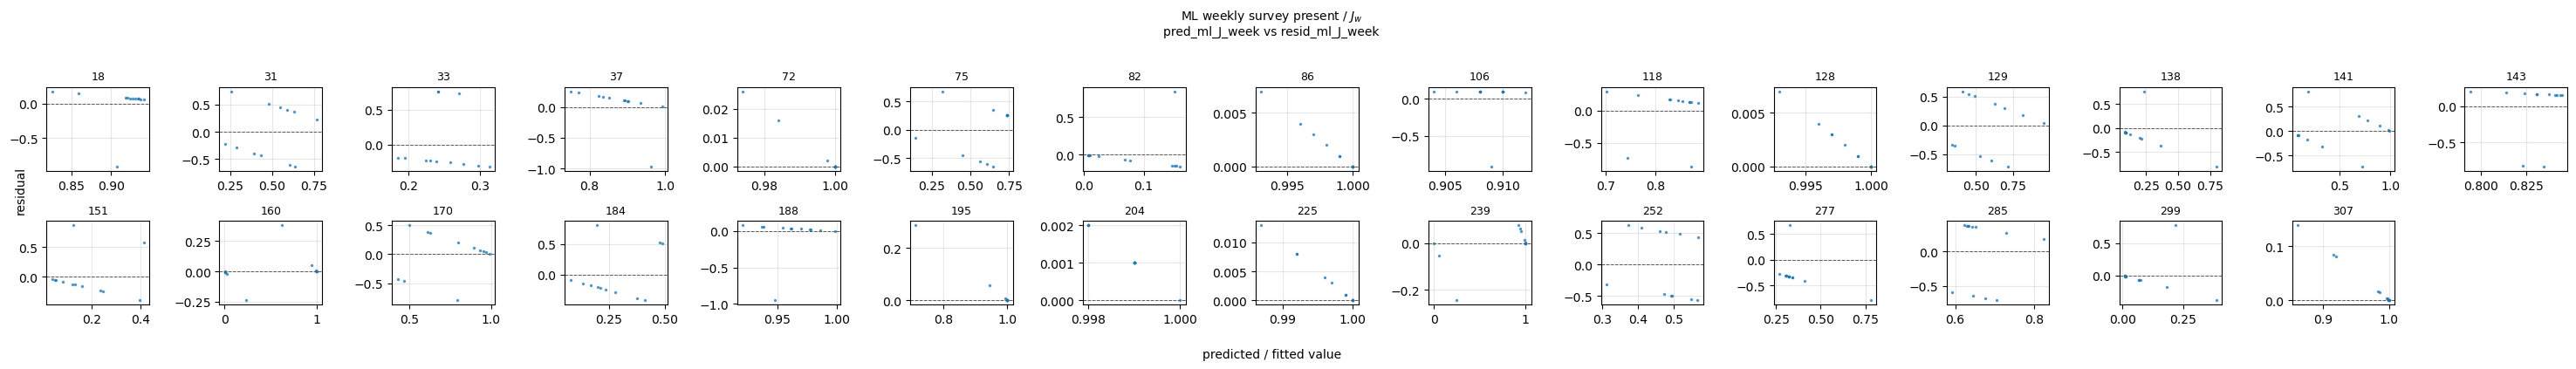

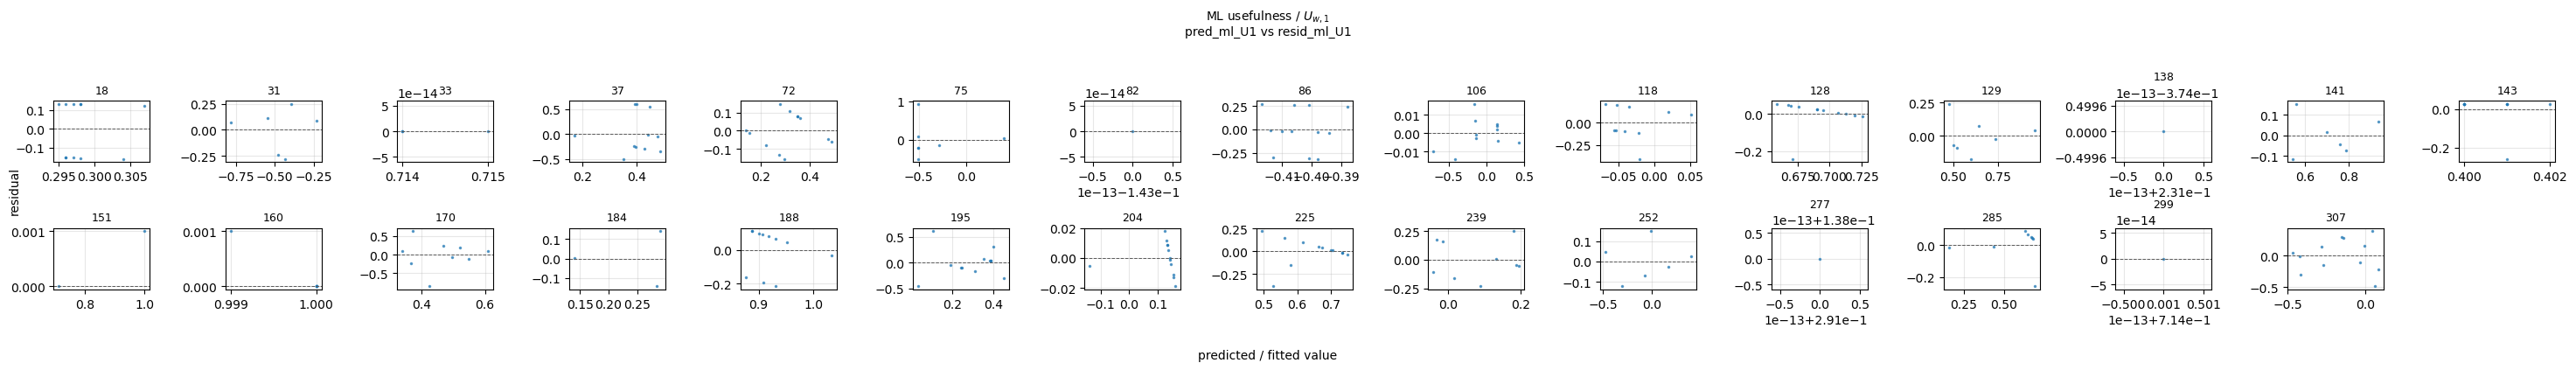

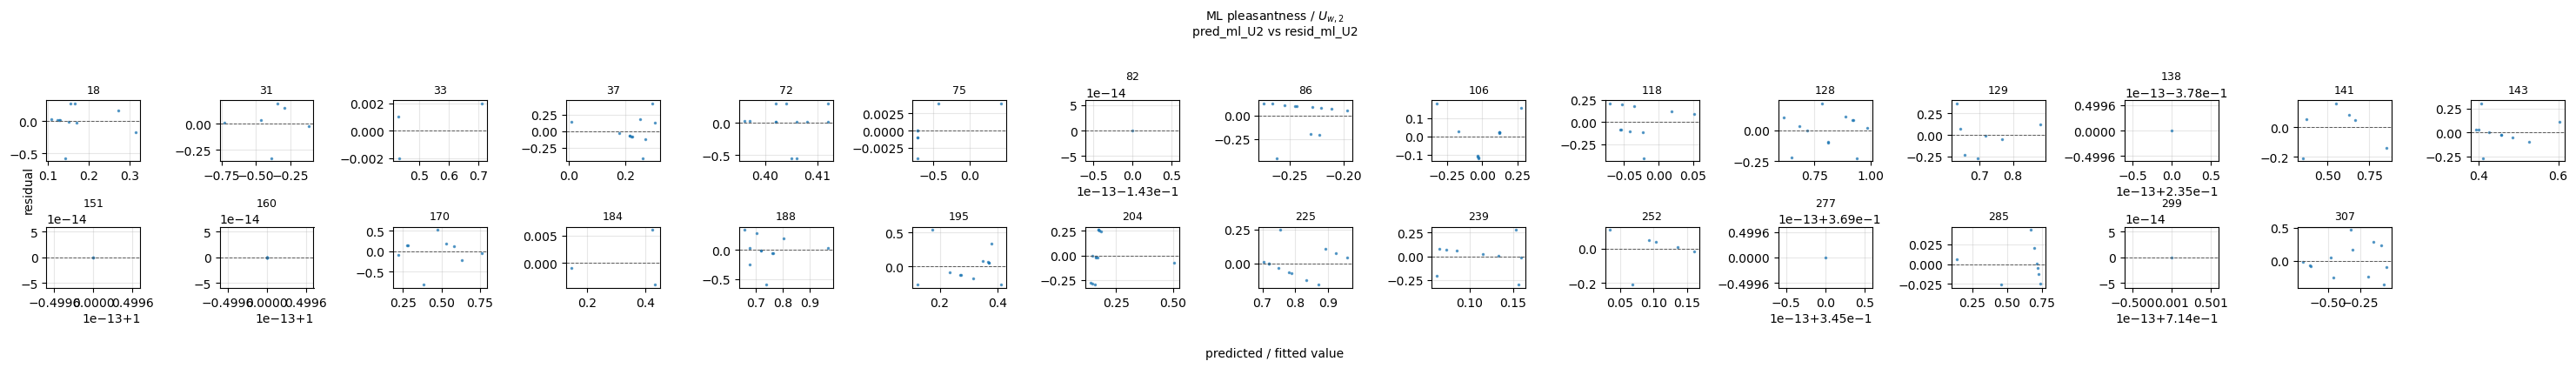

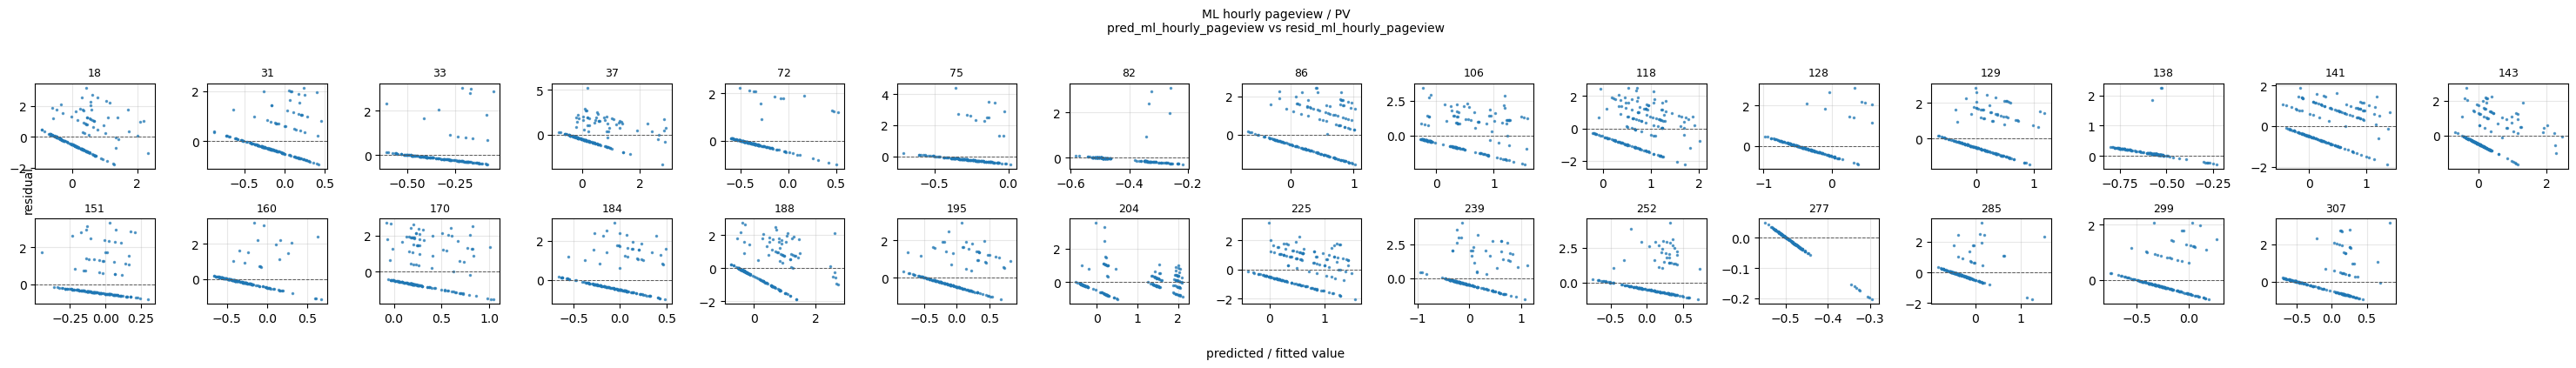

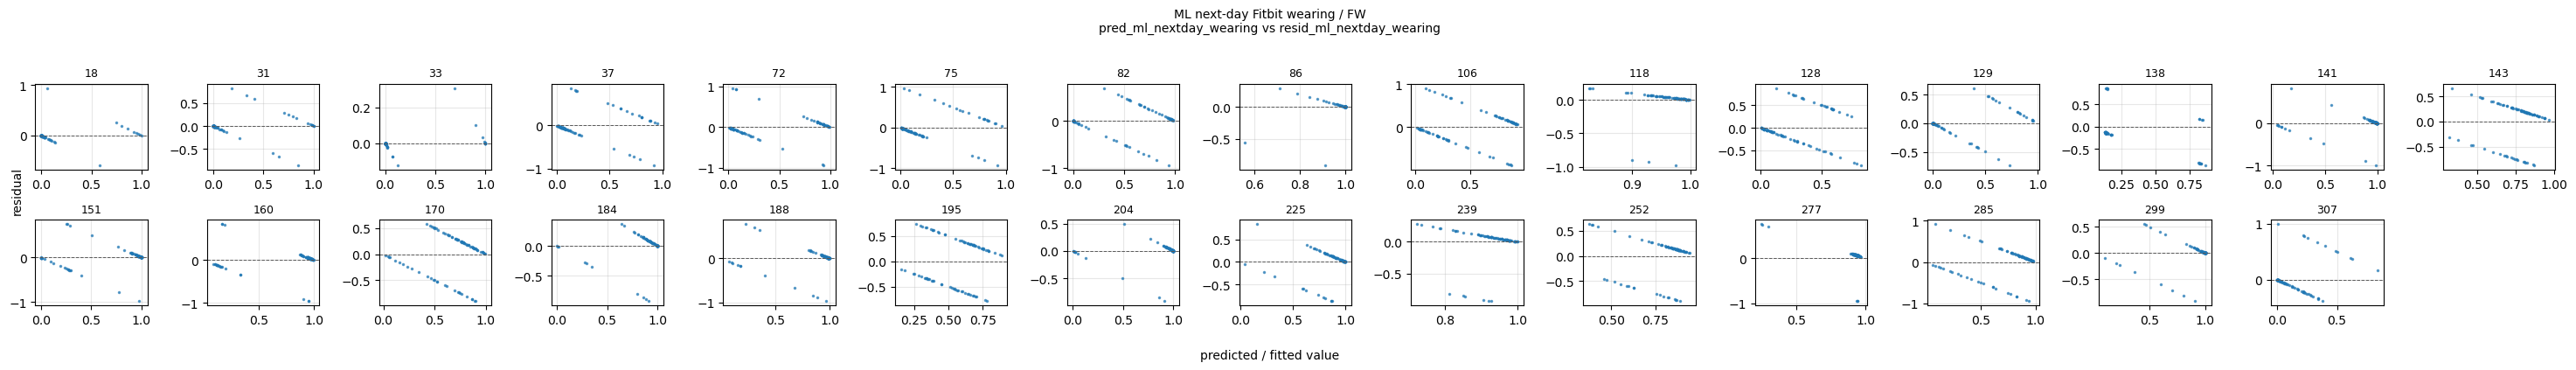

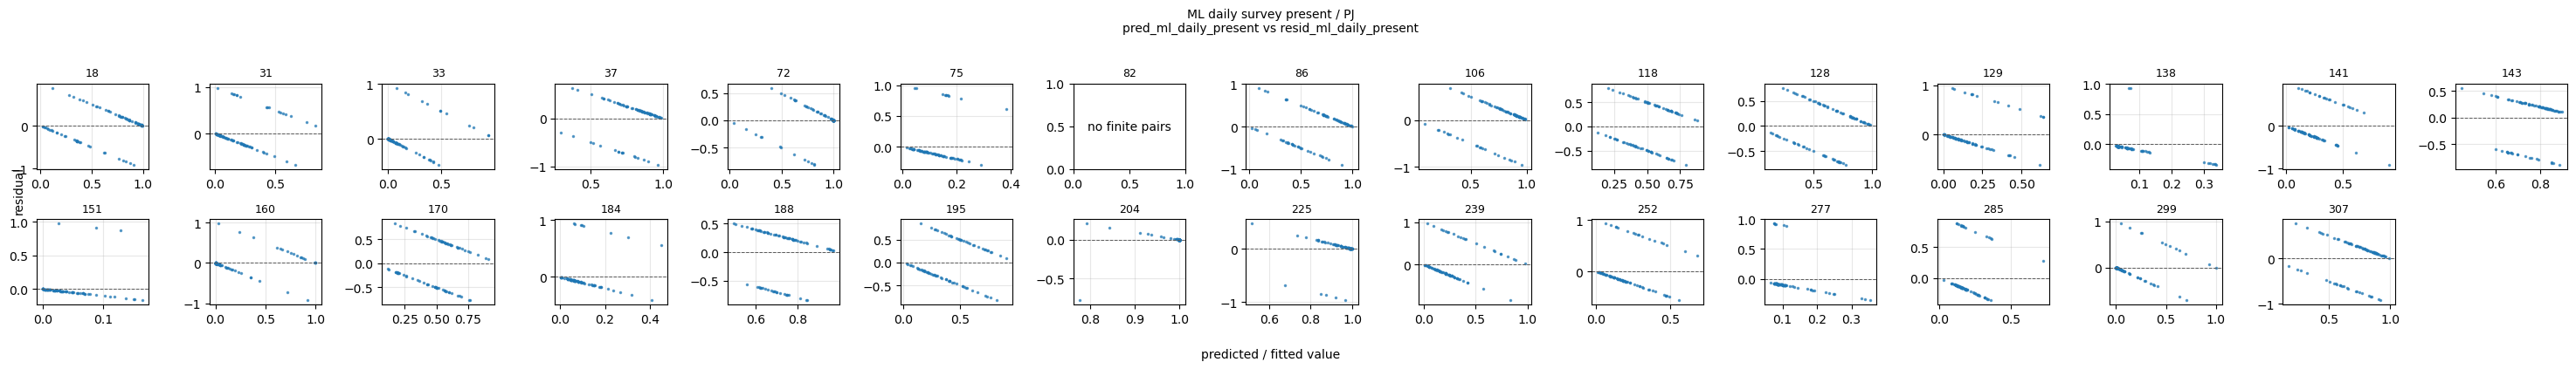

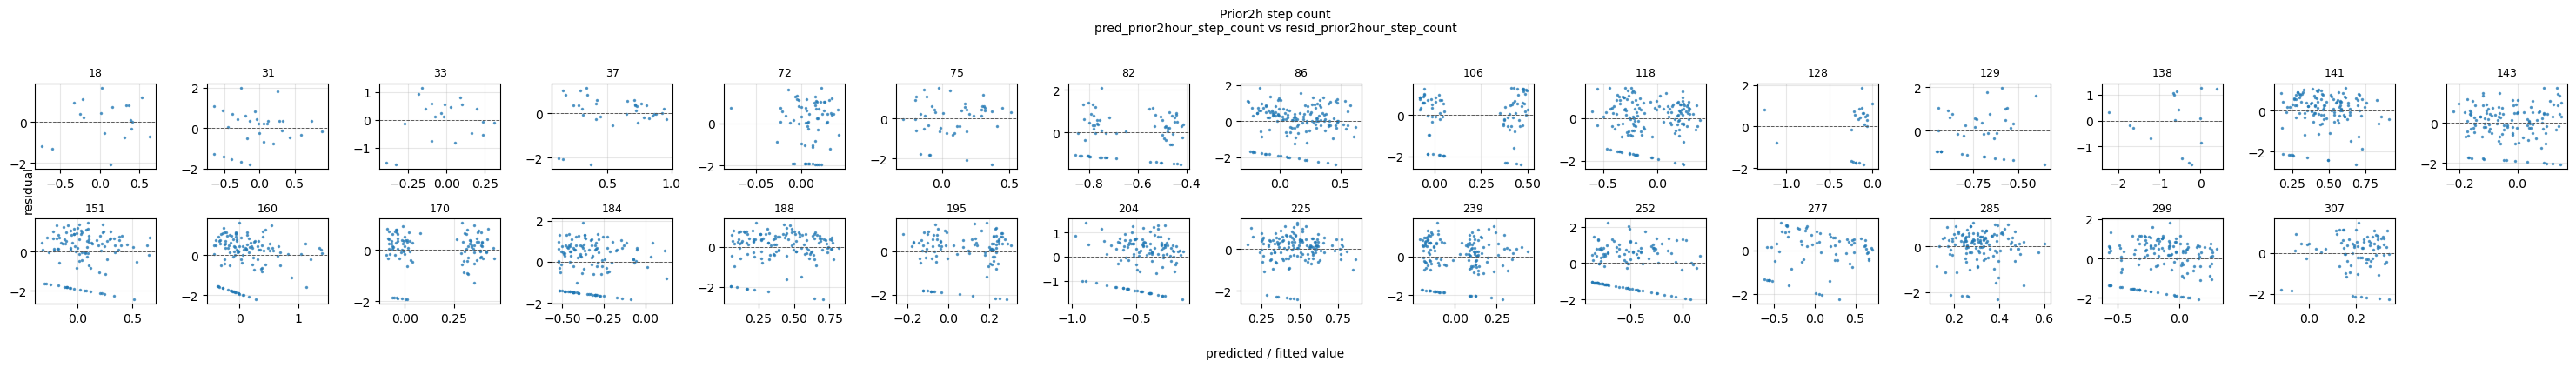

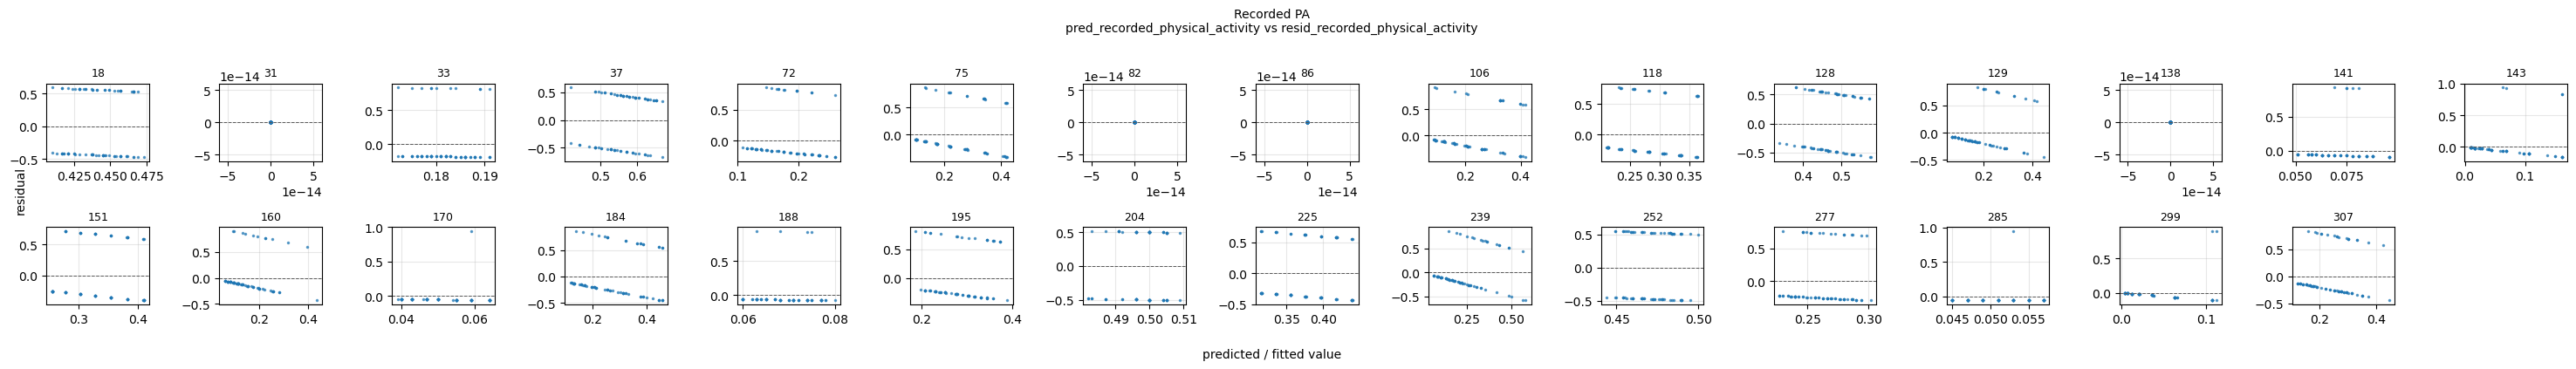

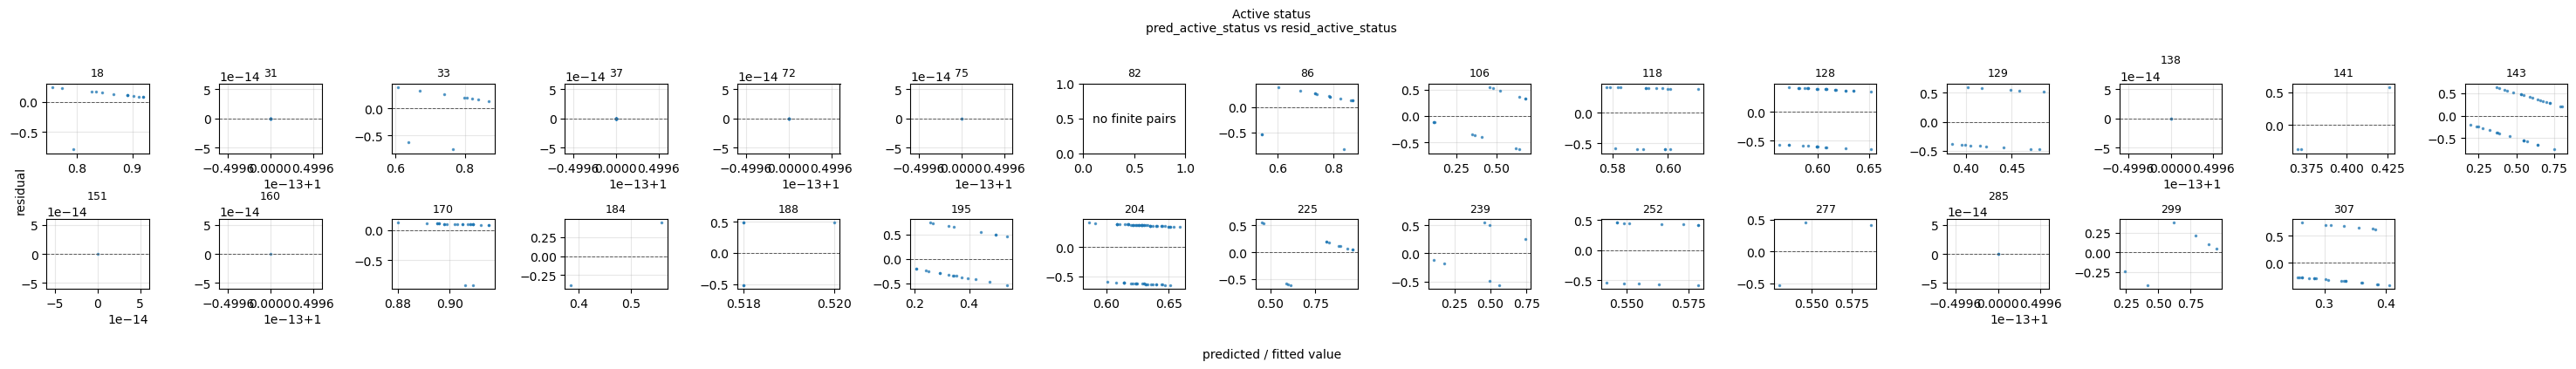

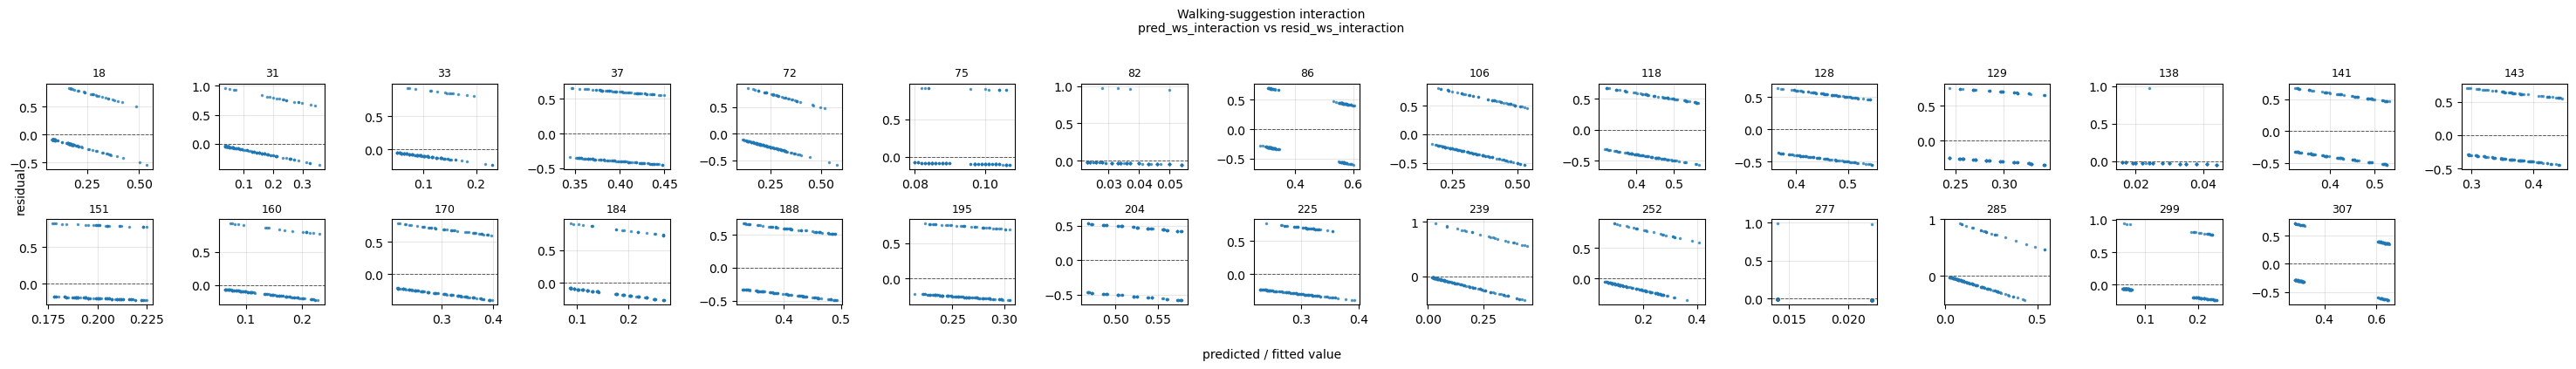

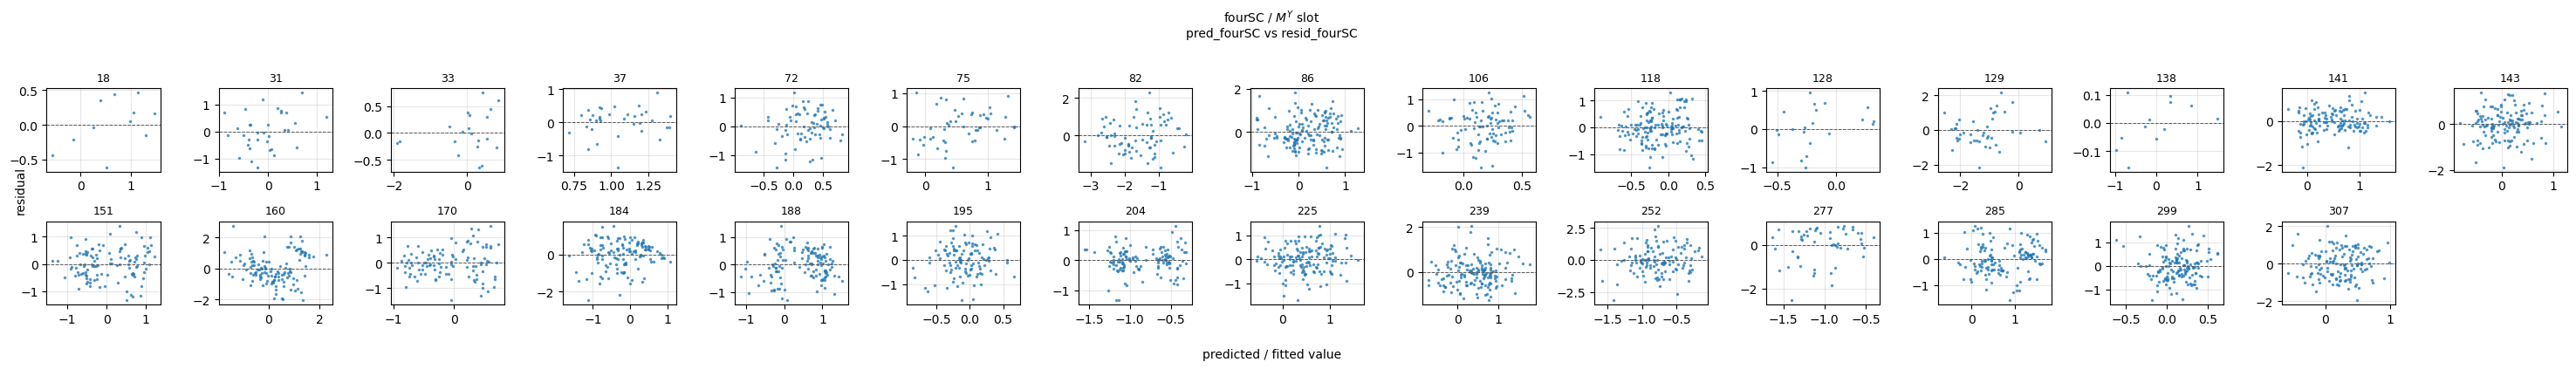

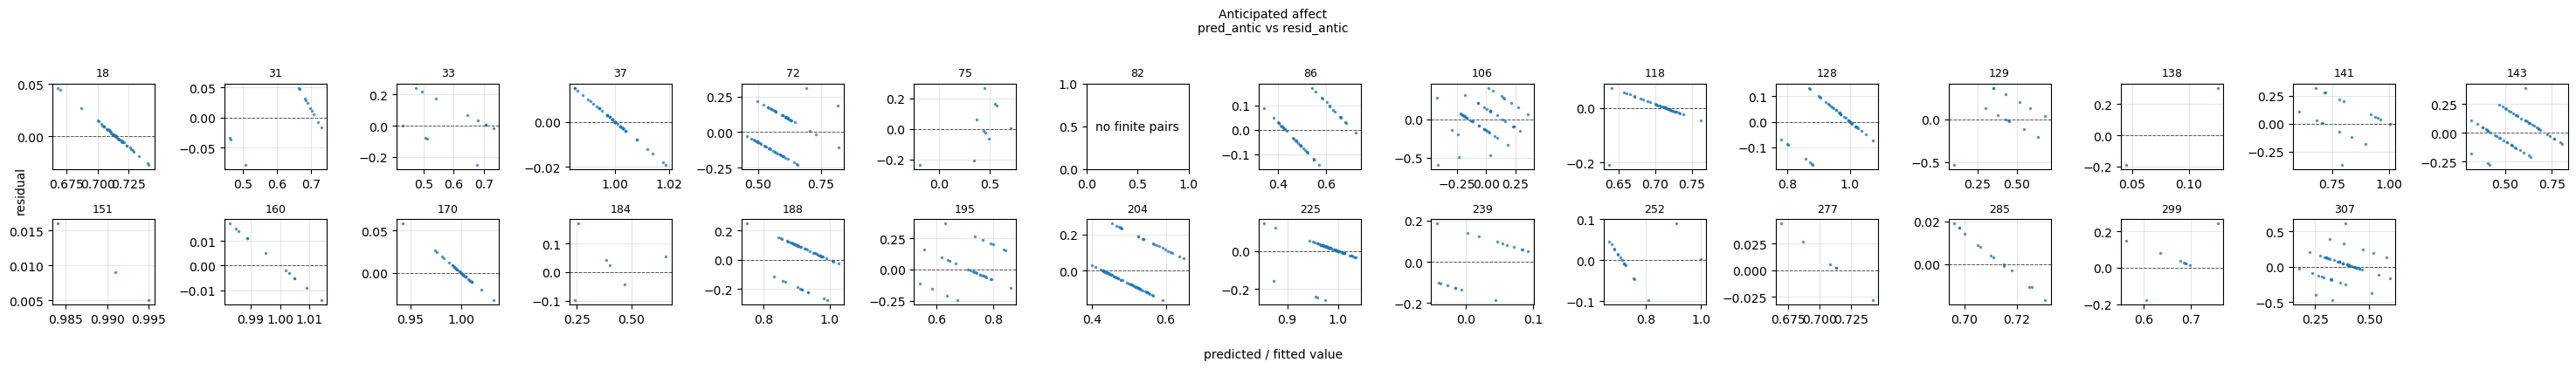

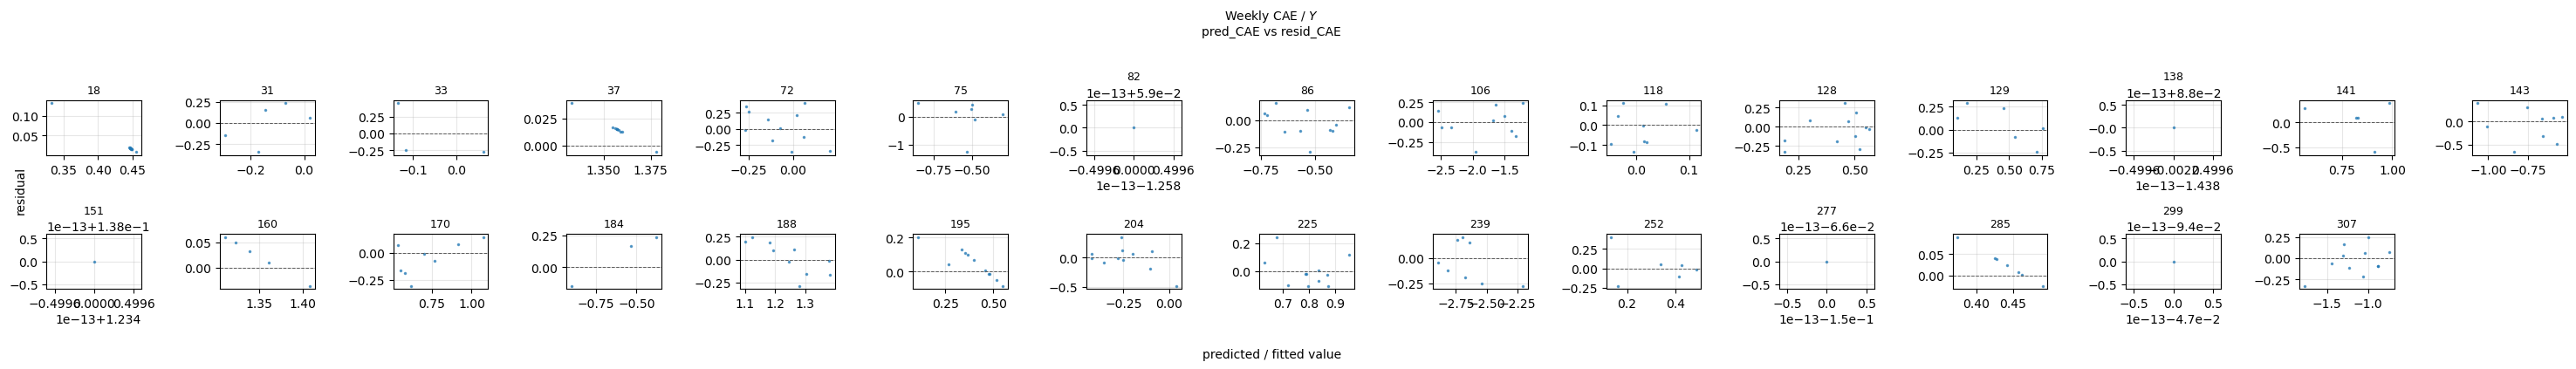

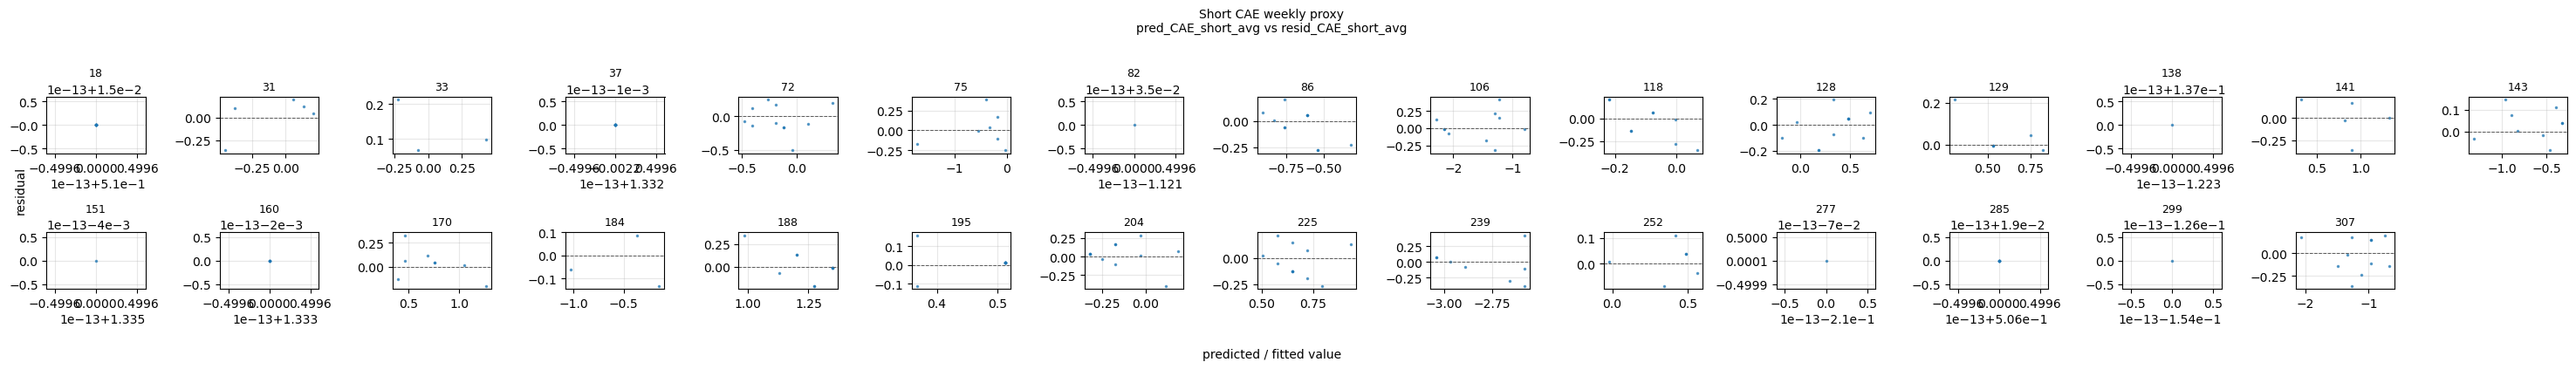

In [28]:
# Residual vs fitted (predicted) value for current `4_perceived_utility.py` and `5_fit_vanilla_testbed.py` outputs.

RESID_PRED_PAIRS = [
    # 4_perceived_utility.py joint ML outputs
    ("resid_ml_J_week", "pred_ml_J_week", r"ML weekly survey present / $J_w$"),
    ("resid_ml_U1", "pred_ml_U1", r"ML usefulness / $U_{w,1}$"),
    ("resid_ml_U2", "pred_ml_U2", r"ML pleasantness / $U_{w,2}$"),
    ("resid_ml_hourly_pageview", "pred_ml_hourly_pageview", r"ML hourly pageview / PV"),
    ("resid_ml_nextday_wearing", "pred_ml_nextday_wearing", r"ML next-day Fitbit wearing / FW"),
    ("resid_ml_daily_present", "pred_ml_daily_present", r"ML daily survey present / PJ"),

    # 5_fit_vanilla_testbed.py vanilla mediator/outcome outputs
    ("resid_prior2hour_step_count", "pred_prior2hour_step_count", r"Prior2h step count"),
    ("resid_recorded_physical_activity", "pred_recorded_physical_activity", r"Recorded PA"),
    ("resid_active_status", "pred_active_status", r"Active status"),
    ("resid_ws_interaction", "pred_ws_interaction", r"Walking-suggestion interaction"),
    ("resid_fourSC", "pred_fourSC", r"fourSC / $M^Y$ slot"),
    ("resid_antic", "pred_antic", r"Anticipated affect"),
    ("resid_CAE", "pred_CAE", r"Weekly CAE / $Y$"),
    ("resid_CAE_short_avg", "pred_CAE_short_avg", "Short CAE weekly proxy"),
]


def _plot_pred_vs_resid(resid_key: str, pred_key: str, title: str, *, alpha: float = 0.65):
    fig, axes, ncols = _resid_axes(len(userid_all))
    any_plotted = False
    for i, uid in enumerate(userid_all):
        pj = Path(file_pred_prefix + str(int(uid)) + ".json")
        ej = Path(file_params_env_prefix + str(int(uid)) + ".json")
        ax = axes[i // ncols, i % ncols]
        if not pj.is_file() or not ej.is_file():
            ax.set_visible(False)
            continue
        predicted = json.loads(pj.read_text(encoding="utf-8"))
        params = json.loads(ej.read_text(encoding="utf-8"))
        if pred_key not in predicted or resid_key not in params:
            ax.set_visible(False)
            continue
        pred = np.asarray(predicted[pred_key], dtype=float)
        resid = np.asarray(params[resid_key], dtype=float)
        pred, resid = _align_pred_resid(pred, resid)
        if pred.size == 0:
            ax.set_title(str(uid), fontsize=9)
            ax.text(0.5, 0.5, "no finite pairs", ha="center", va="center", transform=ax.transAxes)
            continue
        any_plotted = True
        ax.grid(True, alpha=0.3)
        ax.plot(pred, resid, ".", alpha=alpha, markersize=3)
        ax.axhline(0.0, color="0.35", linewidth=0.7, linestyle="--")
        ax.set_title(str(uid), fontsize=9)
        xpad = 0.06 * (np.nanmax(pred) - np.nanmin(pred) + 1e-12)
        ypad = 0.06 * (np.nanmax(resid) - np.nanmin(resid) + 1e-12)
        ax.set_xlim(np.nanmin(pred) - xpad, np.nanmax(pred) + xpad)
        ax.set_ylim(np.nanmin(resid) - ypad, np.nanmax(resid) + ypad)
    for k in range(len(userid_all), 2 * ncols):
        axes[k // ncols, k % ncols].set_visible(False)
    fig.suptitle(f"{title}\n{pred_key} vs {resid_key}", fontsize=10, y=1.02)
    fig.supxlabel("predicted / fitted value", fontsize=10)
    fig.supylabel("residual", fontsize=10)
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    if not any_plotted:
        print(f"(no panels for {resid_key} — missing keys or empty data)")


for rk, pk, ttl in RESID_PRED_PAIRS:
    _plot_pred_vs_resid(rk, pk, ttl)
